In [50]:
# ------ Module Import ------ #
import os
import time
import pickle
import joblib
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, classification_report,
    accuracy_score, confusion_matrix, f1_score, roc_curve, auc
)
from sklearn.pipeline import Pipeline
import umap.umap_ as umap

In [51]:
RAND_SEED = 7 
DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), "Data")
RESULTS_DIR = os.path.join(os.path.dirname(os.getcwd()), "Results")
PLOT_DIR = os.path.join(os.path.dirname(os.getcwd()), "Plots")
MODEL_DIR = os.path.join(os.path.dirname(os.getcwd()), "Models")

for d in [DATA_DIR, RESULTS_DIR, PLOT_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

In [52]:
#Loading the stratified split dataset

spv_dataset = joblib.load(os.path.join(DATA_DIR, "spv_split_dataset_100hvg.pkl"))
print(f"Loaded dataset with {len(spv_dataset['y_train'])} train samples")

Loaded dataset with 53825 train samples


In [53]:
#Extracting the dataset components
X_train = spv_dataset["X_train"]
X_val = spv_dataset["X_val"]
X_test = spv_dataset["X_test"]
y_train = spv_dataset["y_train"]
y_val = spv_dataset["y_val"]
y_test = spv_dataset["y_test"]
meta_train = spv_dataset["meta_train"]
meta_val = spv_dataset["meta_val"]
meta_test = spv_dataset["meta_test"]
label_encoder = spv_dataset["label_encoder"]
class_weights = spv_dataset["class_weights"]
feature_genes = spv_dataset["feature_genes"]

print("Dataset Shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

print("\nClass Names, Encodings, Split Counts and Weights:")
for i, class_name in enumerate(label_encoder.classes_):
    count_train = np.sum(y_train == i)
    count_val = np.sum(y_val == i)
    count_test = np.sum(y_test == i)
    total_count = count_train + count_val + count_test
    weight = class_weights.get(i, "N/A")
    print(f"Class {i:<2} = {class_name:<15} | Train: {count_train:<5} | Val: {count_val:<5} | Test: {count_test:<5} | Total: {total_count:<5} | Weight: {weight:.4f}")

print("\nFeature dtype sanity check:")
print(f"X_train dtype: {X_train.dtypes.unique() if hasattr(X_train, 'dtypes') else X_train.dtype}")
print(f"y_train dtype: {y_train.dtype}")

Dataset Shapes:
X_train: (53825, 100)
X_val:   (11534, 100)
X_test:  (11534, 100)

Class Names, Encodings, Split Counts and Weights:
Class 0  = B intermediate  | Train: 2438  | Val: 523   | Test: 522   | Total: 3483  | Weight: 1.5770
Class 1  = B memory        | Train: 1535  | Val: 329   | Test: 329   | Total: 2193  | Weight: 2.5047
Class 2  = B naive         | Train: 5360  | Val: 1148  | Test: 1148  | Total: 7656  | Weight: 0.7173
Class 3  = CD14 Mono       | Train: 6769  | Val: 1450  | Test: 1451  | Total: 9670  | Weight: 0.5680
Class 4  = CD16 Mono       | Train: 4445  | Val: 953   | Test: 953   | Total: 6351  | Weight: 0.8649
Class 5  = CD4 Naive       | Train: 4980  | Val: 1067  | Test: 1067  | Total: 7114  | Weight: 0.7720
Class 6  = CD4 TCM         | Train: 6475  | Val: 1387  | Test: 1388  | Total: 9250  | Weight: 0.5938
Class 7  = CD4 TEM         | Train: 935   | Val: 200   | Test: 200   | Total: 1335  | Weight: 4.1119
Class 8  = CD8 Naive       | Train: 6350  | Val: 1361  | Te

# Linear Ridge CLassifier

### Training

In [13]:
from sklearn.frozen import FrozenEstimator

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeClassifier(
        alpha=1.0,
        class_weight=class_weights,
        random_state=RAND_SEED
    ))
])

print("Training Ridge classifier...")
ridge_pipeline.fit(X_train, y_train)

y_val_pred_ridge = ridge_pipeline.predict(X_val)

# RidgeClassifier doesn't output probabilities natively — calibrate to get them
calibrated_ridge = CalibratedClassifierCV(
    FrozenEstimator(ridge_pipeline),
    method="sigmoid"
)
calibrated_ridge.fit(X_val, y_val)
y_val_proba_ridge = calibrated_ridge.predict_proba(X_val)

print("\nRidge Classifier - Classification Report")
print(classification_report(y_val, y_val_pred_ridge, target_names=label_encoder.classes_))

Training Ridge classifier...

Ridge Classifier - Classification Report
                 precision    recall  f1-score   support

 B intermediate       0.64      0.55      0.59       523
       B memory       0.53      0.58      0.56       329
        B naive       0.84      0.84      0.84      1148
      CD14 Mono       0.96      0.95      0.96      1450
      CD16 Mono       0.94      0.97      0.95       953
      CD4 Naive       0.59      0.74      0.66      1067
        CD4 TCM       0.90      0.38      0.53      1387
        CD4 TEM       0.34      0.68      0.45       200
      CD8 Naive       0.75      0.84      0.79      1361
        CD8 TCM       0.59      0.63      0.61       360
        CD8 TEM       0.94      0.81      0.87      1296
Dendritic cells       0.96      0.95      0.96       394
             NK       0.95      0.98      0.97       913
           Treg       0.26      0.82      0.39       153

       accuracy                           0.78     11534
      macro avg

### Performance Metrics

In [15]:
# Calculate overall accuracy
accuracy = accuracy_score(y_val, y_val_pred_ridge)
weighted_f1 = f1_score(y_val, y_val_pred_ridge, average="weighted")
macro_f1 = f1_score(y_val, y_val_pred_ridge, average="macro")

print(f"\nRidge Classifier Performance:")
print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Weighted F1-Score: {weighted_f1:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")

# Per-class performance
class_report = classification_report(
    y_val, y_val_pred_ridge,
    target_names=label_encoder.classes_,
    output_dict=True
)
class_metrics = pd.DataFrame(class_report).T
class_metrics = class_metrics.sort_values(by="f1-score", ascending=False)

# Drop summary rows by name (robust to sort order, unlike positional slicing)
summary_rows = ["accuracy", "macro avg", "weighted avg"]
class_metrics_only = class_metrics.drop(index=[r for r in summary_rows if r in class_metrics.index])

print("\nTop 5 best-classified cell types:")
print(class_metrics_only.head(5)[["precision", "recall", "f1-score", "support"]])

print("\nBottom 5 worst-classified cell types:")
print(class_metrics_only.tail(5)[["precision", "recall", "f1-score", "support"]])


Ridge Classifier Performance:
Overall Accuracy: 0.7817
Weighted F1-Score: 0.7829
Macro F1-Score: 0.7237

Top 5 best-classified cell types:
                 precision    recall  f1-score  support
NK                0.954255  0.982475  0.968160    913.0
Dendritic cells   0.959079  0.951777  0.955414    394.0
CD14 Mono         0.957064  0.953103  0.955079   1450.0
CD16 Mono         0.935091  0.967471  0.951006    953.0
CD8 TEM           0.943089  0.805556  0.868914   1296.0

Bottom 5 worst-classified cell types:
                precision    recall  f1-score  support
B intermediate   0.640798  0.552581  0.593429    523.0
B memory         0.531856  0.583587  0.556522    329.0
CD4 TCM          0.898451  0.376352  0.530488   1387.0
CD4 TEM          0.339196  0.675000  0.451505    200.0
Treg             0.259794  0.823529  0.394984    153.0


### Confusion Matrix, ROC/AUC curve and Precision REcall curve

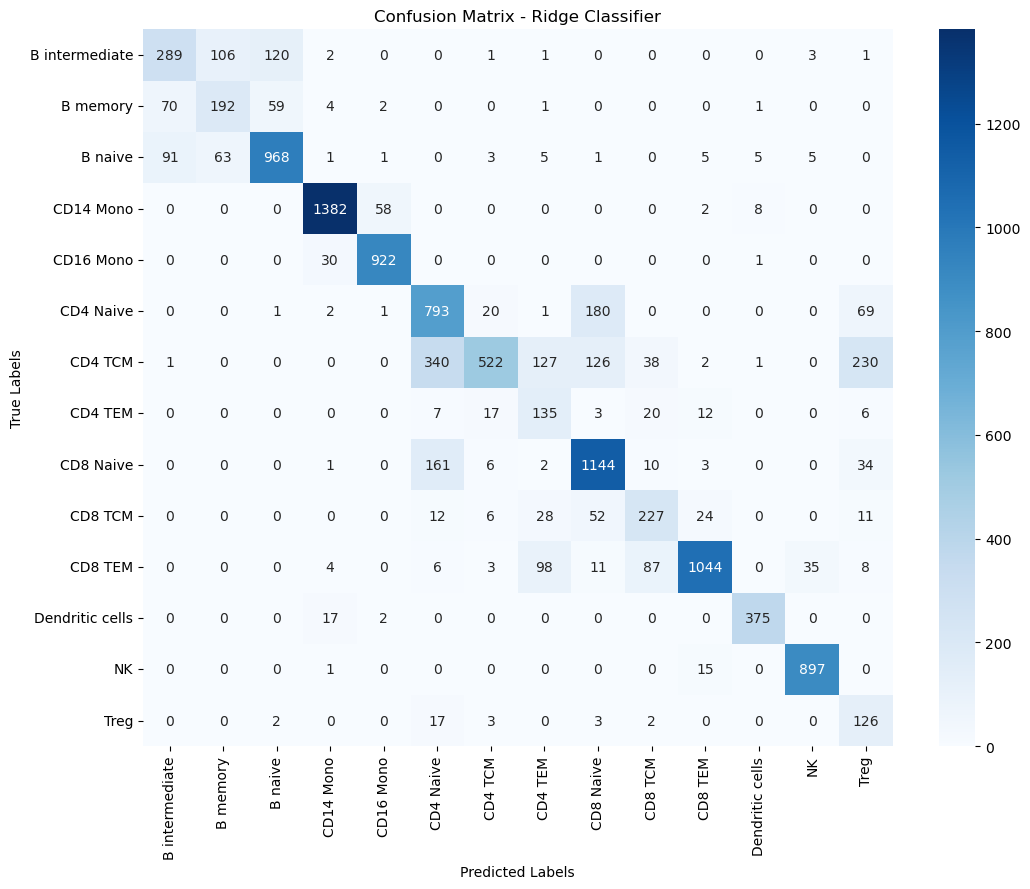

In [16]:
cm_ridge = confusion_matrix(y_val, y_val_pred_ridge)

plt.figure(figsize=(11, 9))
sns.heatmap(
    cm_ridge, 
    annot=True, 
    fmt="d", 
    cmap="Blues",
    xticklabels=label_encoder.classes_, 
    yticklabels=label_encoder.classes_
)
plt.title("Confusion Matrix - Ridge Classifier")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "confusion_matrix_ridge.png"), dpi=300, bbox_inches="tight")
plt.show()

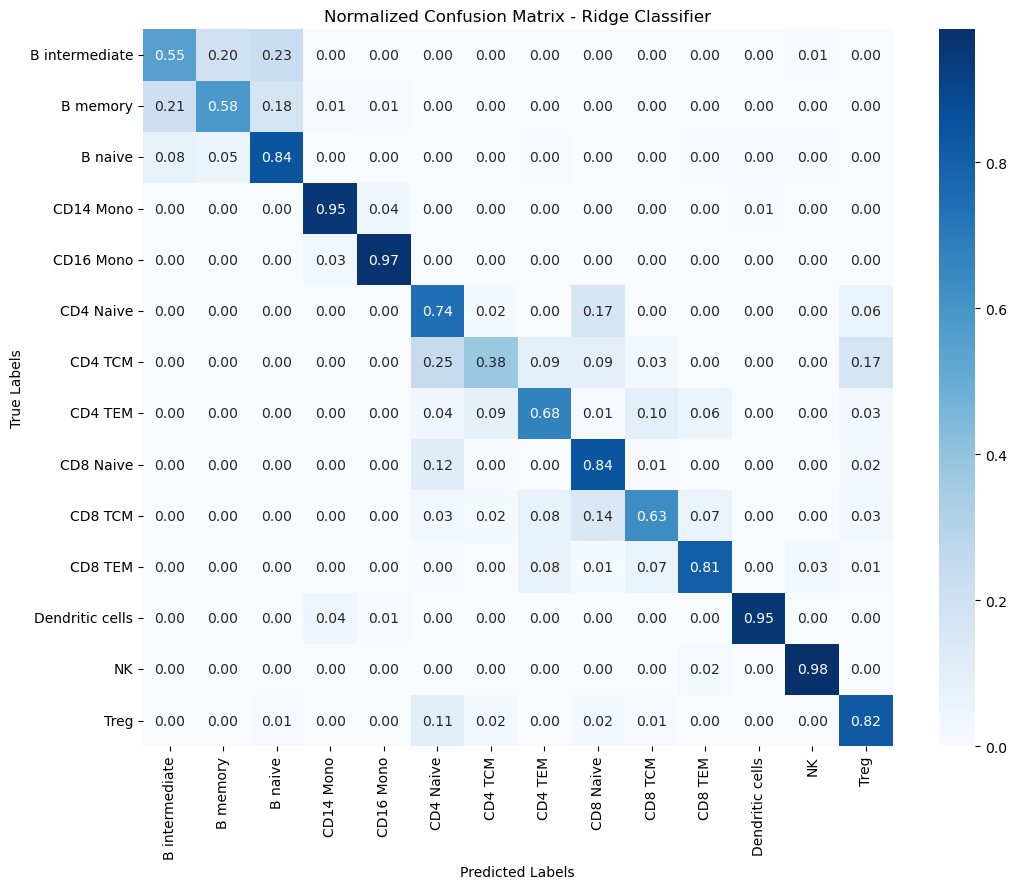

In [17]:
cm_ridge_norm = cm_ridge.astype("float") / cm_ridge.sum(axis=1, keepdims=True)

plt.figure(figsize=(11, 9))
sns.heatmap(
    cm_ridge_norm, annot=True, 
    fmt=".2f", 
    cmap="Blues",
    xticklabels=label_encoder.classes_, 
    yticklabels=label_encoder.classes_
)
plt.title("Normalized Confusion Matrix - Ridge Classifier")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "normalized_confusion_matrix_ridge.png"), dpi=300, bbox_inches="tight")
plt.show()

The confusion matrix reveals two distinct, biologically interpretable error patterns among the poorly-performing classes. CD4 TCM's low recall (0.38) is driven by scattering across multiple related T-cell states — 25% of true CD4 TCM cells are misclassified as CD4 Naive, 17% as Treg — rather than a single dominant confusion, consistent with CD4 TCM's intermediate transcriptional position between naive and effector states. Treg's low precision (0.26), meanwhile, traces predominantly to a single source: 17% of true CD4 TCM cells (230 of 1387) are misclassified as Treg, making CD4 TCM the dominant contributor to Treg's false positives. The B-cell subtypes (B intermediate, B memory, B naive) show a symmetric three-way confusion pattern, consistent with their known transcriptional similarity established during EDA. In contrast, well-separated lineages — NK (0.98), CD16 Mono (0.97), Dendritic cells (0.95), CD14 Mono (0.95) — show near-perfect diagonal dominance with minimal cross-contamination.

In [18]:
# Binarize the validation labels for one-vs-rest ROC/PR curves
y_val_bin = label_binarize(y_val, classes=np.unique(y_train))
n_classes = y_val_bin.shape[1]

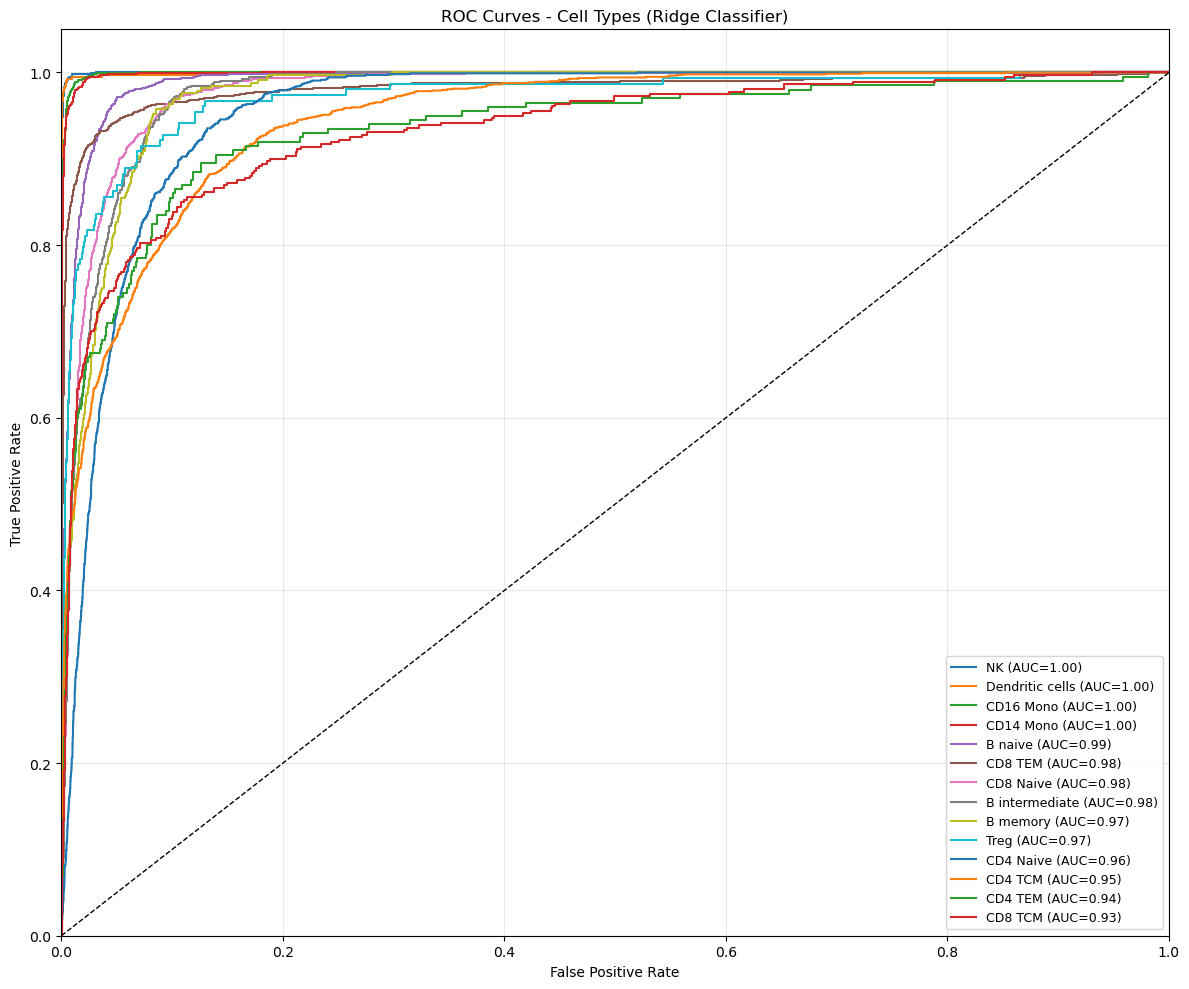

In [22]:
# ROC Curves : one per cell type, colored/labeled individually
plt.figure(figsize=(12, 10))

roc_results = []
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_val_proba_ridge[:, i])
    roc_auc = auc(fpr, tpr)
    class_name = label_encoder.classes_[i]
    roc_results.append((roc_auc, class_name, fpr, tpr))

roc_results.sort(key=lambda x: x[0], reverse=True)

for roc_auc, class_name, fpr, tpr in roc_results:
    plt.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Cell Types (Ridge Classifier)")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "roc_curve_ridge.png"), dpi=300, bbox_inches="tight")
plt.show()

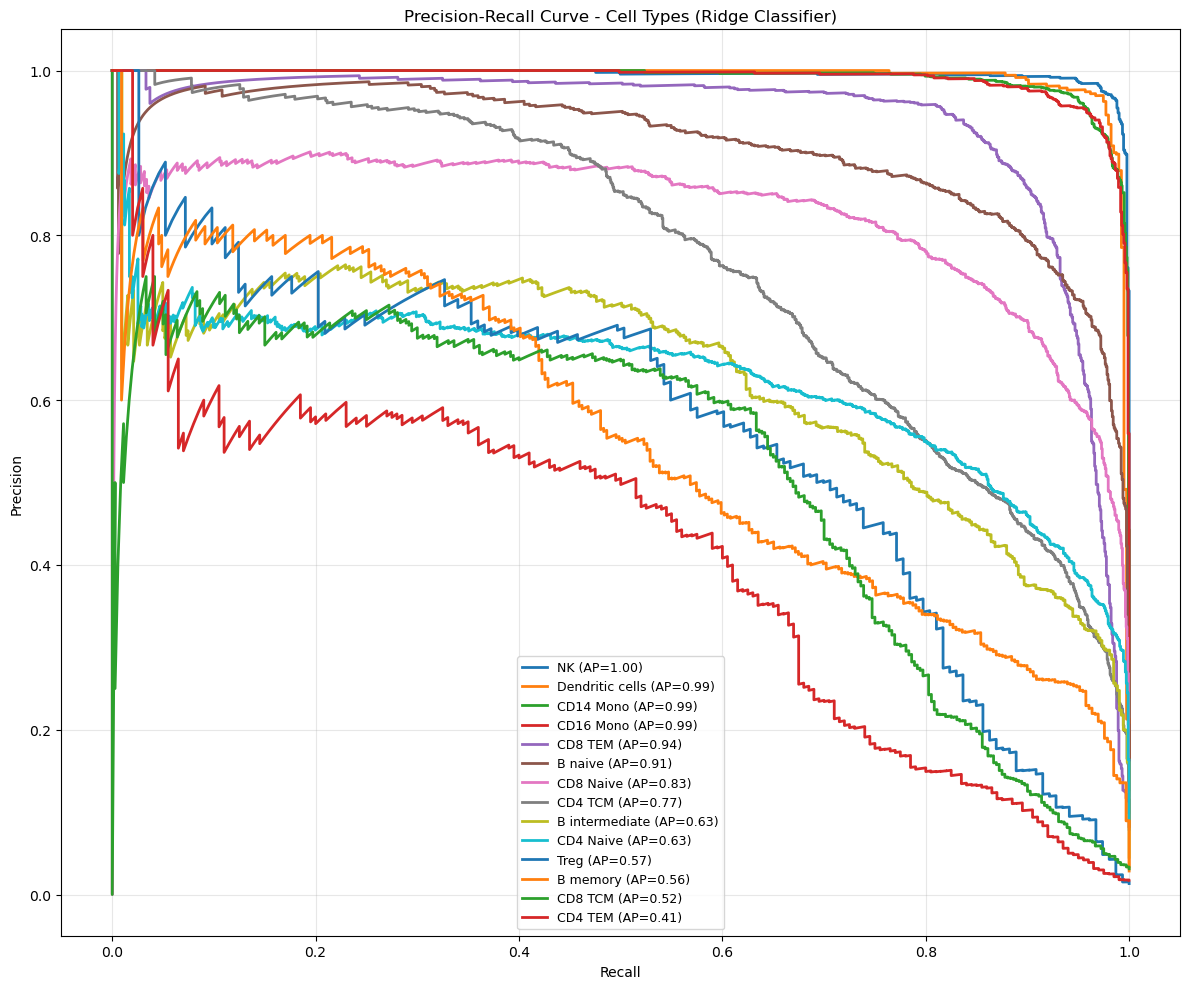

In [23]:
# Precision-Recall Curves, one per cell type
plt.figure(figsize=(12, 10))

pr_results = []
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_val_proba_ridge[:, i])
    ap_score = average_precision_score(y_val_bin[:, i], y_val_proba_ridge[:, i])
    class_name = label_encoder.classes_[i]
    pr_results.append((ap_score, class_name, recall, precision))

pr_results.sort(key=lambda x: x[0], reverse=True)

for ap_score, class_name, recall, precision in pr_results:
    plt.plot(recall, precision, lw=2, label=f"{class_name} (AP={ap_score:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Cell Types (Ridge Classifier)")
plt.legend(loc="best", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "pr_curve_ridge.png"), dpi=300, bbox_inches="tight")
plt.show()

Comparing the ROC and Precision-Recall curves reveals a discrepancy that's especially informative given the class imbalance in this dataset. By AUC, most classes look strong — even Treg (0.97), CD8 TCM (0.93), and CD4 TEM (0.94) appear to have solid discriminative power. But Average Precision tells a different story: Treg (AP=0.57), CD8 TCM (AP=0.52), B memory (AP=0.56), and CD4 TEM (AP=0.41) all rank at the bottom, consistent with the low-precision, high-false-positive pattern already observed in the confusion matrix. This divergence is expected on imbalanced data — ROC-AUC is computed against a very large negative class, making even a mediocre classifier look strong, while AP is sensitive specifically to how often positive predictions are correct. For this dataset, Average Precision is the more trustworthy indicator of real-world reliability for the minority classes.

### UMAP visualization for comparing predicted classes with ground truth labels

Generating UMAP embedding for visualization...


/home/rajan/miniforge3/envs/immune_ml_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


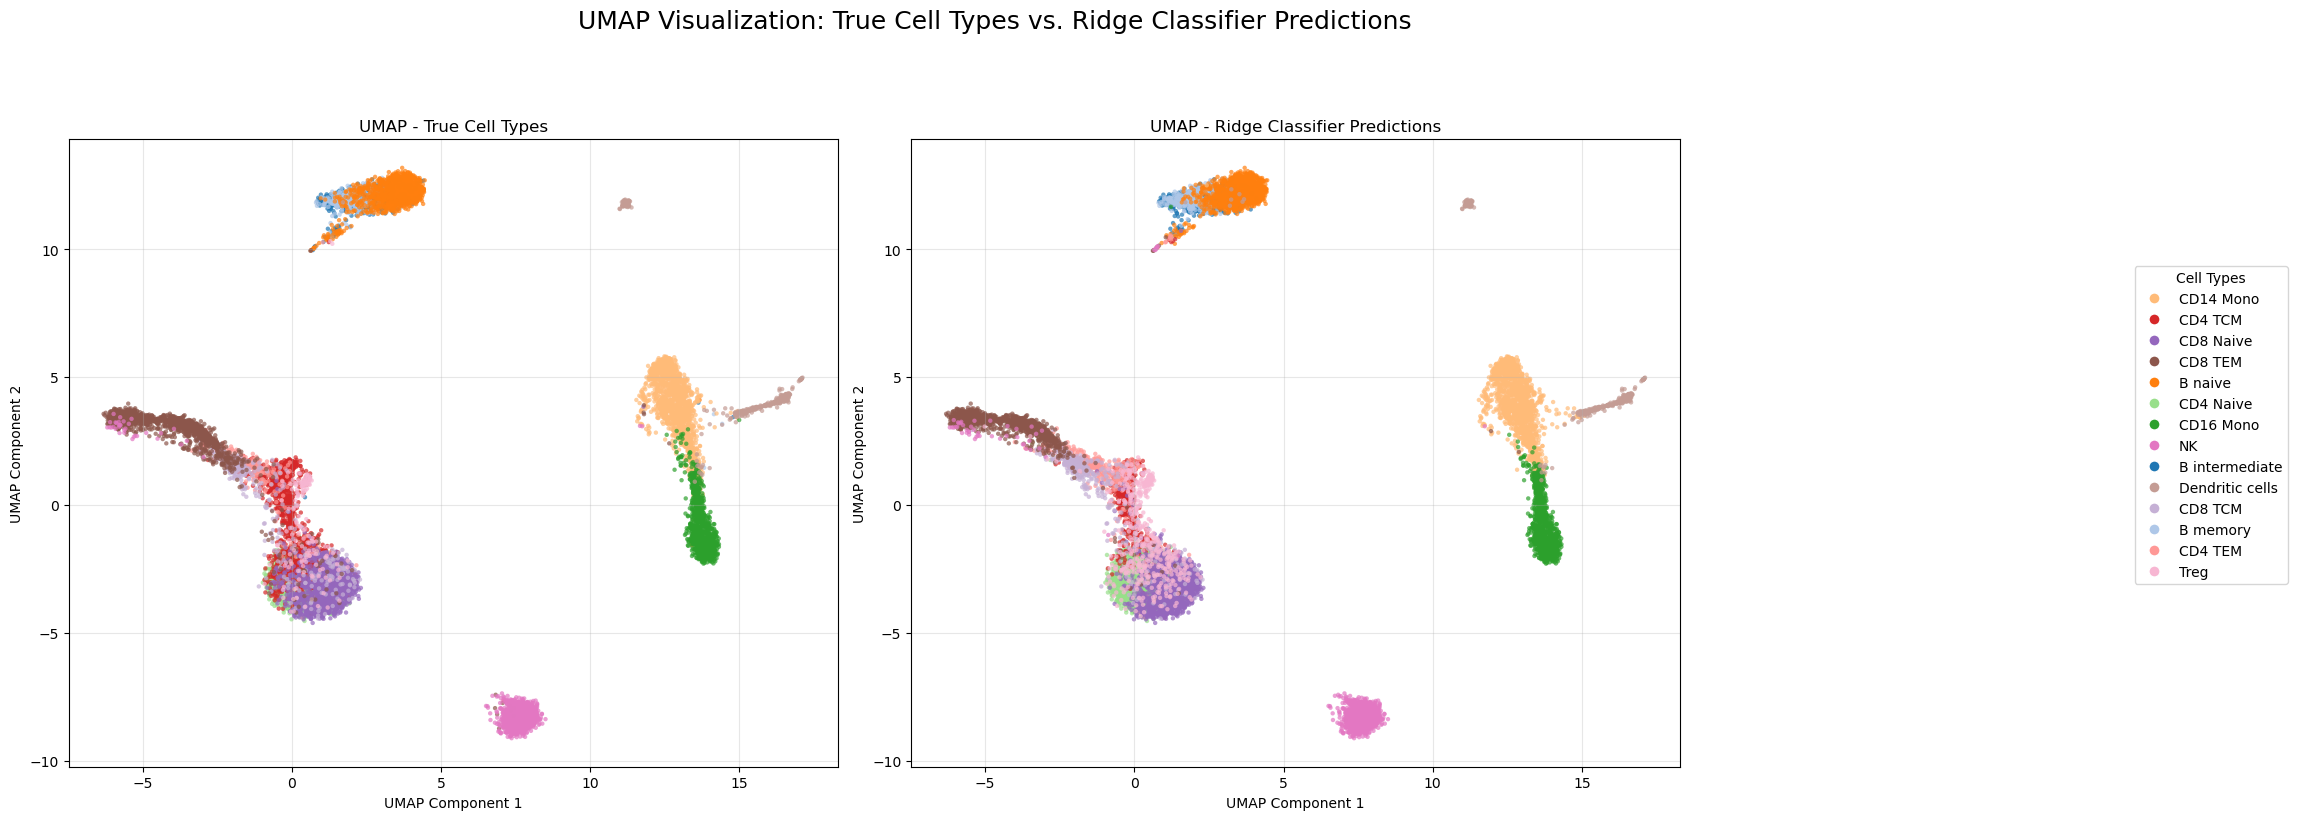

In [24]:
print("Generating UMAP embedding for visualization...")
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.3, random_state=RAND_SEED)
X_val_umap = reducer.fit_transform(X_val)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

unique_cell_types = np.unique(meta_val["CellType"])
n_colors = len(unique_cell_types)
color_palette = sns.color_palette("tab20", n_colors=min(20, n_colors))
color_palette += sns.color_palette("tab20b", n_colors=max(0, n_colors - 20))
color_dict = {cell_type: color_palette[i % len(color_palette)] for i, 
              cell_type in enumerate(unique_cell_types)}

# Plot 1: True Cell Types
for cell_type in unique_cell_types:
    mask = (meta_val["CellType"] == cell_type)
    ax1.scatter(X_val_umap[mask, 0], 
                X_val_umap[mask, 1], 
                s=10, 
                color=color_dict[cell_type], 
                label=cell_type, 
                alpha=0.7, 
                edgecolor="none")
ax1.set_title("UMAP - True Cell Types")
ax1.set_xlabel("UMAP Component 1")
ax1.set_ylabel("UMAP Component 2")
ax1.grid(alpha=0.3)

# Plot 2: Ridge Classifier Predictions
predicted_cell_types = label_encoder.inverse_transform(y_val_pred_ridge)
for cell_type in unique_cell_types:
    mask = (predicted_cell_types == cell_type)
    ax2.scatter(X_val_umap[mask, 0], 
                X_val_umap[mask, 1], 
                s=10, 
                color=color_dict[cell_type], 
                label=cell_type, 
                alpha=0.7, 
                edgecolor="none")
ax2.set_title("UMAP - Ridge Classifier Predictions")
ax2.set_xlabel("UMAP Component 1")
ax2.set_ylabel("UMAP Component 2")
ax2.grid(alpha=0.3)

# Legend for all cell types, ordered by abundance (largest first)
cell_type_counts = {ct: (meta_val["CellType"] == ct).sum() for ct in unique_cell_types}
ordered_cell_types = sorted(unique_cell_types, key=lambda ct: cell_type_counts[ct], reverse=True)

handles = [plt.Line2D([0], [0], 
                      marker="o", 
                      color="w", 
                      markerfacecolor=color_dict[ct], 
                      markersize=8) for ct in ordered_cell_types]
labels = list(ordered_cell_types)

fig.legend(handles, 
           labels, 
           loc="center right", 
           title="Cell Types", 
           bbox_to_anchor=(1.15, 0.5), 
           ncol=1, 
           fontsize=10)

plt.suptitle("UMAP Visualization: True Cell Types vs. Ridge Classifier Predictions", fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.savefig(os.path.join(PLOT_DIR, "umap_ridge_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

The UMAP comparison confirms the confusion matrix findings visually. Well-separated islands in true-label space (B naive/intermediate/memory, NK, CD14/CD16 Mono, Dendritic cells) remain clean in the predicted-label panel, consistent with their high F1 scores. The elongated lower-left arm, containing CD8 TEM, CD8 Naive, CD4 TCM, CD4 TEM, Treg, CD8 TCM, and CD4 Naive, already shows substantial color intermixing in the true-label panel itself, reflecting real transcriptional similarity between these T-cell subsets rather than a modeling failure alone. The predicted-label panel mirrors this same mixing pattern closely, indicating the Ridge Classifier's errors are concentrated exactly where the underlying biology makes clean separation genuinely difficult, not in regions that are cleanly separated in truth but scrambled by the model.

### Misclassification Analysis

In [25]:
# Create a DataFrame for misclassification analysis
misclass_df = pd.DataFrame({
    "True_Cell_Type": label_encoder.inverse_transform(y_val),
    "Predicted_Cell_Type": label_encoder.inverse_transform(y_val_pred_ridge),
    "UMAP_1": X_val_umap[:, 0],
    "UMAP_2": X_val_umap[:, 1]
})
misclass_df["Correctly_Classified"] = misclass_df["True_Cell_Type"] == misclass_df["Predicted_Cell_Type"]

print(f"Overall misclassification rate: {(~misclass_df['Correctly_Classified']).mean():.4f}")

Overall misclassification rate: 0.2183


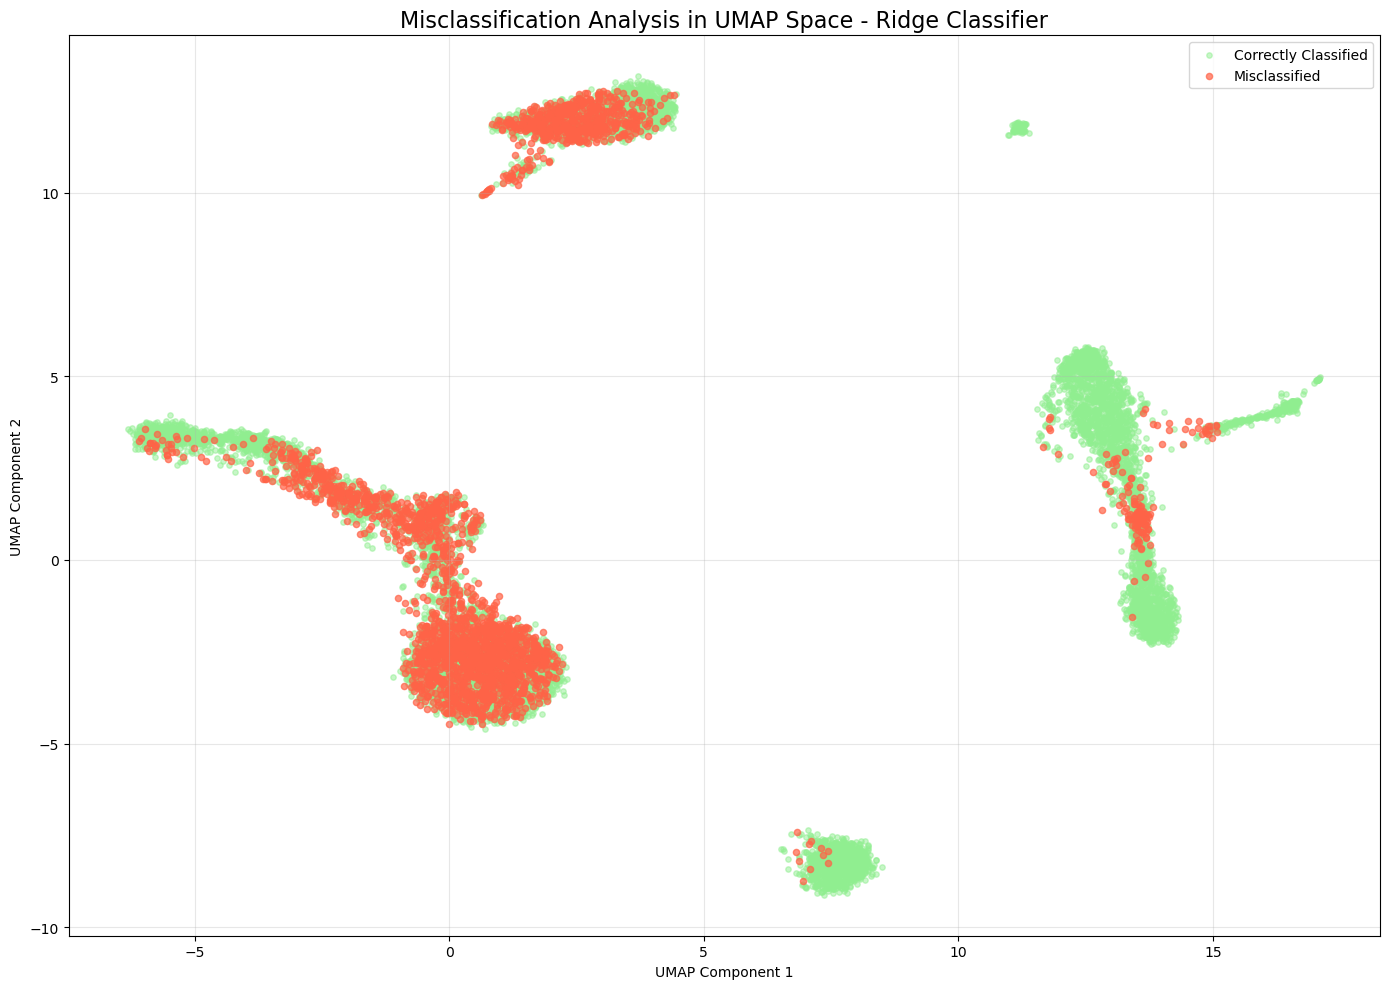

In [27]:
# Plot misclassifications in UMAP space
plt.figure(figsize=(14, 10))
plt.scatter(
    misclass_df[misclass_df["Correctly_Classified"]]["UMAP_1"],
    misclass_df[misclass_df["Correctly_Classified"]]["UMAP_2"],
    c="lightgreen", s=15, alpha=0.5, label="Correctly Classified"
)
plt.scatter(
    misclass_df[~misclass_df["Correctly_Classified"]]["UMAP_1"],
    misclass_df[~misclass_df["Correctly_Classified"]]["UMAP_2"],
    c="tomato", s=20, alpha=0.7, label="Misclassified"
)
plt.title("Misclassification Analysis in UMAP Space - Ridge Classifier",fontsize=16)
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "ridge_misclassification_umap.png"), dpi=300, bbox_inches="tight")
plt.show()

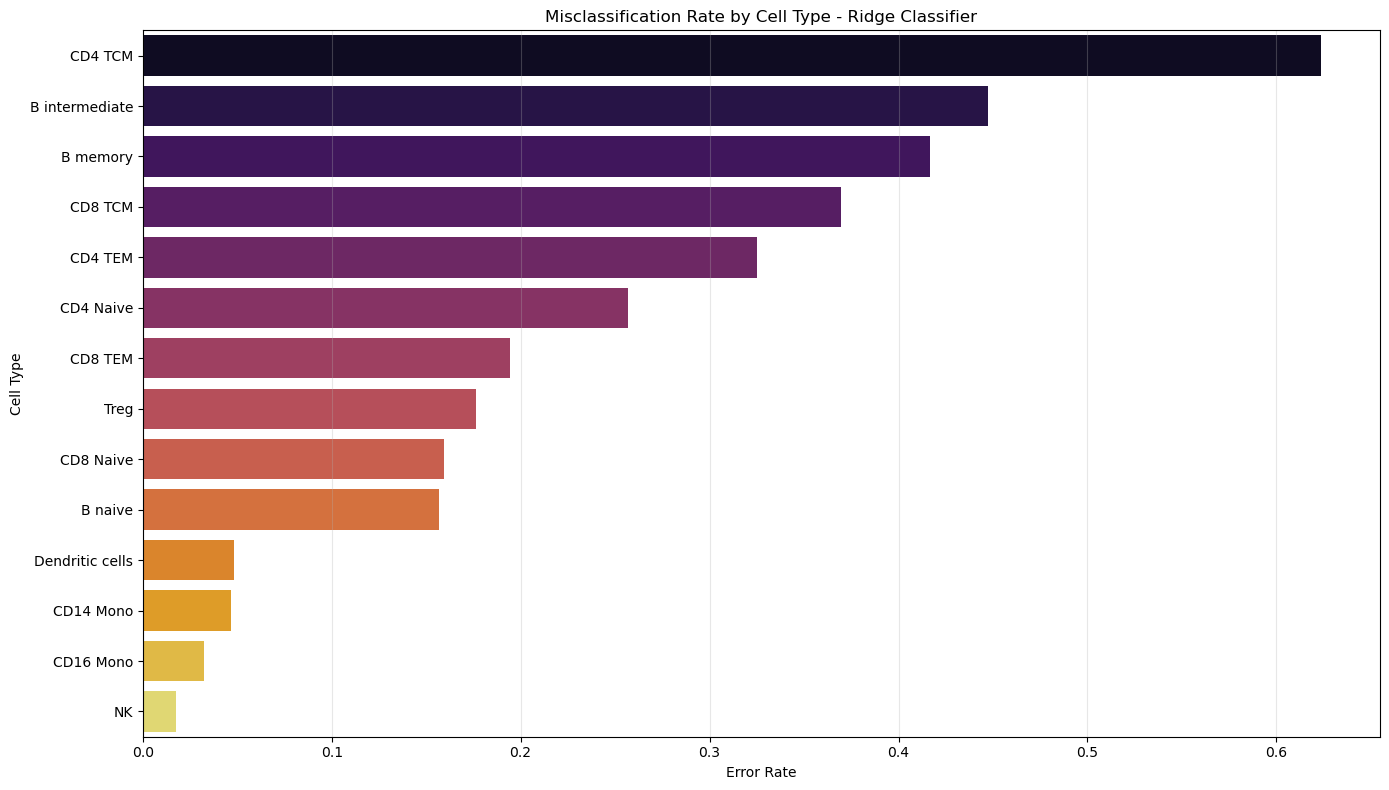

In [34]:
# Misclassification rates by cell type (all 14 classes)
misclass_rates = misclass_df.groupby("True_Cell_Type")["Correctly_Classified"].agg(
    ["count", lambda x: (~x).sum(), lambda x: (~x).sum() / len(x)]
).reset_index()
misclass_rates.columns = ["Cell_Type", "Total_Cells", "Misclassified_Cells", "Error_Rate"]
misclass_rates = misclass_rates.sort_values("Error_Rate", ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(
    data=misclass_rates,
    y="Cell_Type",
    x="Error_Rate",
    hue="Cell_Type",
    palette="inferno",
    legend=False
)
plt.title("Misclassification Rate by Cell Type - Ridge Classifier")
plt.xlabel("Error Rate")
plt.ylabel("Cell Type")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "ridge_top_misclassified_types.png"), dpi=300, bbox_inches="tight")
plt.show()

In [29]:
# Most common misclassification pairs
misclass_pairs = misclass_df[~misclass_df["Correctly_Classified"]].groupby(
    ["True_Cell_Type", "Predicted_Cell_Type"]
).size().reset_index().rename(columns={0: "Count"})
misclass_pairs = misclass_pairs.sort_values("Count", ascending=False)

print("Most common misclassification pairs (True -> Predicted):")
print(misclass_pairs.head(10))

Most common misclassification pairs (True -> Predicted):
    True_Cell_Type Predicted_Cell_Type  Count
36         CD4 TCM           CD4 Naive    340
42         CD4 TCM                Treg    230
33       CD4 Naive           CD8 Naive    180
50       CD8 Naive           CD4 Naive    161
37         CD4 TCM             CD4 TEM    127
38         CD4 TCM           CD8 Naive    126
1   B intermediate             B naive    120
0   B intermediate            B memory    106
65         CD8 TEM             CD4 TEM     98
13         B naive      B intermediate     91


The misclassification analysis pinpoints CD4 TCM as the single hardest class for the Ridge Classifier, with an error rate exceeding 0.60, well above any other cell type. This single class accounts for three of the six most common misclassification pairs in the dataset: CD4 TCM to CD4 Naive (340 cells), CD4 TCM to Treg (230 cells), and CD4 TCM to CD4 TEM (127 cells), together representing the majority of its own validation samples. Rather than being confused with one neighboring class, CD4 TCM's errors are scattered across four distinct destinations, consistent with its intermediate transcriptional position among CD4 T-cell states. The B-cell subtypes (B naive, B intermediate, B memory) show a separate, genuinely bidirectional confusion triangle, with substantial misclassification flowing in both directions between all three pairs. In UMAP space, these error patterns concentrate almost entirely within the lower-left region containing the T-cell and B-cell subtype clusters, while the well-separated islands (monocytes, dendritic cells, NK) remain nearly free of misclassification, matching their near-zero error rates in the bar chart.

### Feature Importance 

In [30]:
# Extract coefficients from the Ridge classifier
ridge_model = ridge_pipeline.named_steps["ridge"]
coefficients = ridge_model.coef_  # shape: (n_classes, n_features)

print(f"Coefficient matrix shape: {coefficients.shape}")

Coefficient matrix shape: (14, 100)


In [31]:
# Mean absolute coefficient magnitude per gene, averaged across all classes
mean_abs_coef = np.abs(coefficients).mean(axis=0)

feature_importance_df = pd.DataFrame({
    "Gene": feature_genes,
    "Mean_Abs_Coefficient": mean_abs_coef
}).sort_values("Mean_Abs_Coefficient", ascending=False)

print("Top 20 most influential genes (Ridge Classifier):")
print(feature_importance_df.head(20))

Top 20 most influential genes (Ridge Classifier):
       Gene  Mean_Abs_Coefficient
9      CCL5              0.069621
25     GZMA              0.061124
10     CST3              0.046856
18     IL7R              0.045093
33   FCER1G              0.044774
49   FCGR3A              0.044704
5      NKG7              0.040422
13     AIF1              0.039438
12   TYROBP              0.037569
29    IFI30              0.037538
1   HLA-DRA              0.037243
60     CTSW              0.036803
4      GNLY              0.036101
52    CD79A              0.035436
11     IL32              0.035353
40    MS4A1              0.032140
8    S100A4              0.031859
15      LTB              0.030818
38     VCAN              0.029600
48  TNFSF10              0.029448


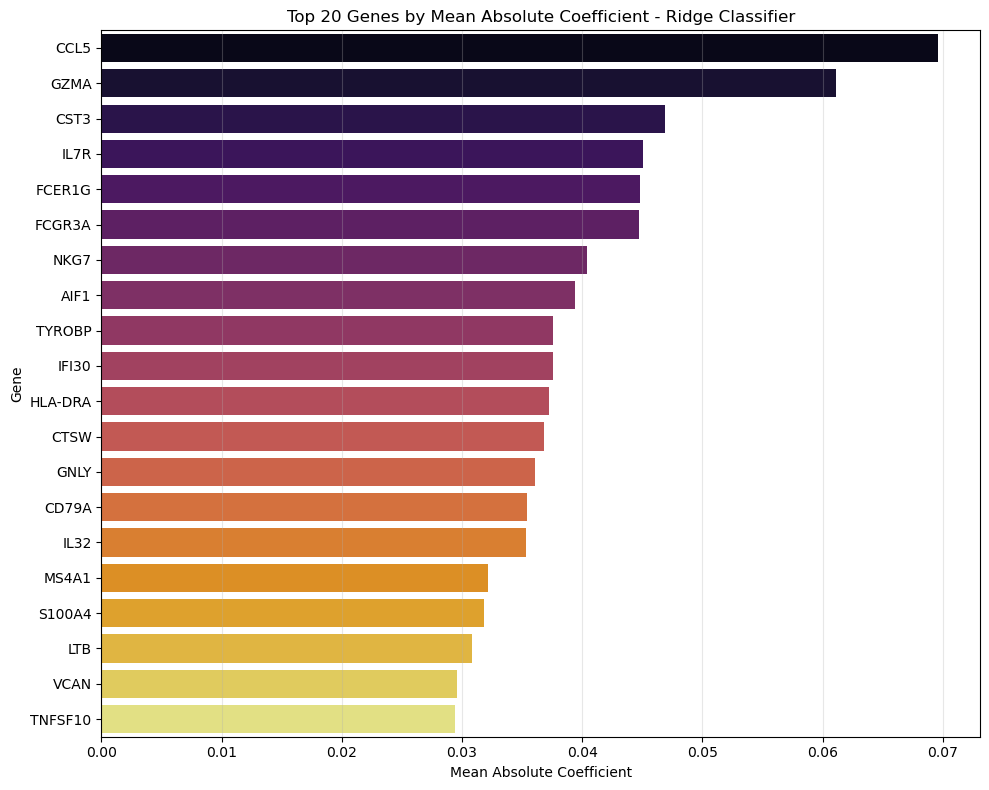

In [37]:
# Plot top 20 genes by mean absolute coefficient
plt.figure(figsize=(10, 8))
top20 = feature_importance_df.head(20)
sns.barplot(
    data=top20,
    y="Gene",
    x="Mean_Abs_Coefficient",
    hue="Gene",
    palette="inferno",
    legend=False
)
plt.title("Top 20 Genes by Mean Absolute Coefficient - Ridge Classifier")
plt.xlabel("Mean Absolute Coefficient")
plt.ylabel("Gene")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "ridge_feature_importance.png"), dpi=300, bbox_inches="tight")
plt.show()

The top genes by mean absolute coefficient show strong convergence with two independent prior analyses. Eight of the top 20 genes here (CST3, HLA-DRA, TYROBP, MS4A1, CD79A, NKG7, IFI30, AIF1) also appeared in the F-statistic based marker gene ranking from the earlier exploratory analysis, despite the two methods measuring entirely different things: F-statistic captures between versus within group variance in raw expression, while Ridge coefficients capture learned discriminative weight in a trained classifier. The top gene, CCL5, along with GZMA, NKG7, and FCGR3A, also match the leading features identified by a Random Forest model in prior work on this dataset. The features span all major lineages present in the data: cytotoxic and effector lymphocyte markers (CCL5, GZMA, NKG7, GNLY, CTSW), myeloid and antigen presentation genes (CST3, TYROBP, AIF1, FCER1G, FCGR3A, IFI30), B cell markers (CD79A, MS4A1), and general T cell markers (IL7R, IL32, LTB), rather than concentrating on a single dominant signal.

### Confidence distribution analysis

In [43]:
# Get prediction confidence for each sample
prediction_confidence = np.max(y_val_proba_ridge, axis=1)
correct_mask = (y_val_pred_ridge == y_val)

confidence_df = pd.DataFrame({
    "Confidence": prediction_confidence,
    "Correct": correct_mask,
    "Cell_Type": label_encoder.inverse_transform(y_val)
})
confidence_df["Prediction"] = confidence_df["Correct"].map({True: "Correct Predictions", False: "Incorrect Predictions"})

print(f"Mean confidence, correct predictions: {confidence_df[confidence_df['Correct']]['Confidence'].mean():.4f}")
print(f"Mean confidence, incorrect predictions: {confidence_df[~confidence_df['Correct']]['Confidence'].mean():.4f}")

Mean confidence, correct predictions: 0.8011
Mean confidence, incorrect predictions: 0.5896


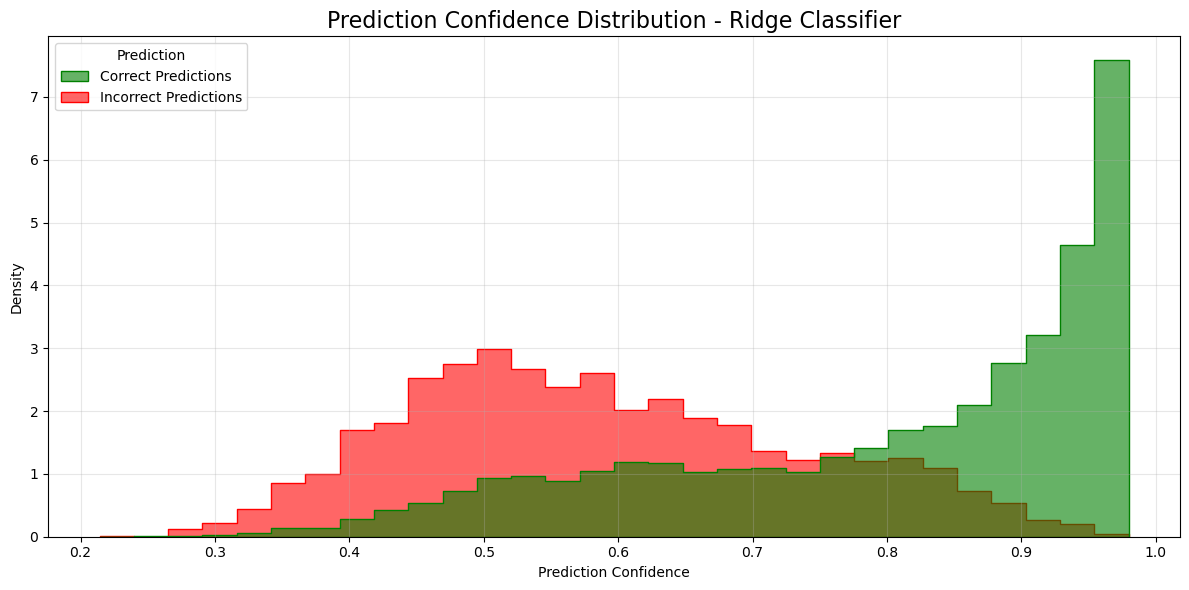

In [44]:
# Plot confidence distributions for correct and incorrect predictions
plt.figure(figsize=(12, 6))
sns.histplot(
    data=confidence_df, x="Confidence", hue="Prediction",
    bins=30, alpha=0.6,
    palette={"Correct Predictions": "green", "Incorrect Predictions": "red"},
    element="step", common_norm=False, stat="density"
)
plt.title("Prediction Confidence Distribution - Ridge Classifier", fontsize=16)
plt.xlabel("Prediction Confidence")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "ridge_confidence_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

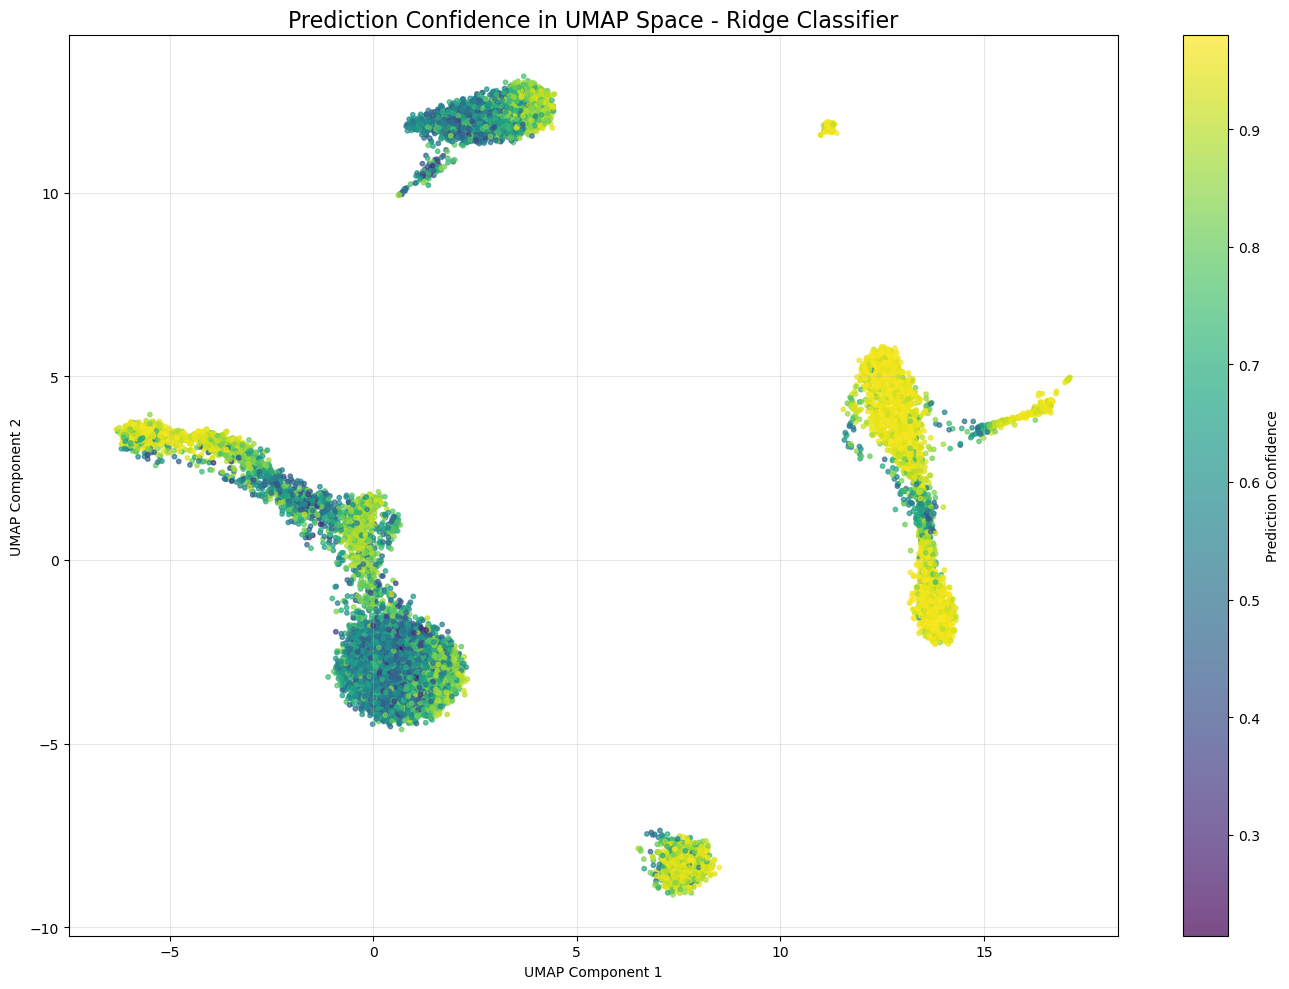

In [45]:
# Visualize confidence levels in UMAP space
plt.figure(figsize=(14, 10))
scatter = plt.scatter(
    X_val_umap[:, 0],
    X_val_umap[:, 1],
    c=prediction_confidence,
    cmap="viridis",
    s=10,
    alpha=0.7
)
plt.colorbar(scatter, label="Prediction Confidence")
plt.title("Prediction Confidence in UMAP Space - Ridge Classifier", fontsize=16)
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "ridge_confidence_umap.png"), dpi=300, bbox_inches="tight")
plt.show()

Mean prediction confidence differs substantially between correct (0.80) and incorrect (0.59) predictions, and the two distributions are visibly distinct rather than overlapping heavily. Correct predictions concentrate near 0.9 to 1.0 confidence, while incorrect predictions peak closer to 0.5, indicating the model tends to be genuinely uncertain rather than confidently wrong when it makes an error. This is a favorable calibration property, since a model that is frequently both wrong and highly confident would be far more concerning for downstream use. The UMAP confidence plot reinforces this pattern spatially: low confidence points concentrate almost entirely within the lower-left region containing CD4 TCM, Treg, CD4 Naive, and related T-cell subtypes, the same region already identified as the primary source of misclassification, while the well-separated monocyte, dendritic cell, B-cell, and NK clusters remain uniformly high confidence.

### Test Eval and Model persistence

In [46]:
# Final evaluation on test set
print("\nEvaluating Ridge Classifier on test set...")
y_test_pred_ridge = ridge_pipeline.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred_ridge)
test_f1_weighted = f1_score(y_test, y_test_pred_ridge, average="weighted")
test_f1_macro = f1_score(y_test, y_test_pred_ridge, average="macro")

print(f"\nTest Set Performance:")
print(f"Overall Accuracy: {test_accuracy:.4f}")
print(f"Weighted F1-Score: {test_f1_weighted:.4f}")
print(f"Macro F1-Score: {test_f1_macro:.4f}")


Evaluating Ridge Classifier on test set...

Test Set Performance:
Overall Accuracy: 0.7789
Weighted F1-Score: 0.7792
Macro F1-Score: 0.7172


In [47]:
# Save the models in a dedicated subfolder
ridge_dir = os.path.join(MODEL_DIR, "Linear_ridge_classifiers")
os.makedirs(ridge_dir, exist_ok=True)

ridge_model_path = os.path.join(ridge_dir, "ridge_classifier.pkl")
joblib.dump(ridge_pipeline, ridge_model_path)
print(f"Ridge classifier model saved to {ridge_model_path}")

calibrated_model_path = os.path.join(ridge_dir, "calibrated_ridge_classifier.pkl")
joblib.dump(calibrated_ridge, calibrated_model_path)
print(f"Calibrated Ridge classifier model saved to {calibrated_model_path}")

Ridge classifier model saved to /mnt/c/Users/rajan/Personal - ASUS/Github_projects/ML_immune_cell_type_classifier/Models/Linear_ridge_classifiers/ridge_classifier.pkl
Calibrated Ridge classifier model saved to /mnt/c/Users/rajan/Personal - ASUS/Github_projects/ML_immune_cell_type_classifier/Models/Linear_ridge_classifiers/calibrated_ridge_classifier.pkl


In [48]:
# Save performance metrics
performance_metrics = {
    "model": "Ridge Classifier",
    "validation_accuracy": accuracy,
    "validation_f1_weighted": weighted_f1,
    "validation_f1_macro": macro_f1,
    "test_accuracy": test_accuracy,
    "test_f1_weighted": test_f1_weighted,
    "test_f1_macro": test_f1_macro
}

pd.DataFrame([performance_metrics]).to_csv(
    os.path.join(RESULTS_DIR, "ridge_classifier_performance.csv"), index=False
)
print("Performance metrics saved to CSV file.")

Performance metrics saved to CSV file.


### Ridge Classifier: Summary

The Ridge Classifier achieved a validation accuracy of 0.7817 (weighted F1 0.7829, macro F1 0.7237) and a test accuracy of 0.7789 (weighted F1 0.7792, macro F1 0.7172). The close agreement between validation and test performance, within 0.3 percentage points on every metric, indicates the model generalizes consistently rather than overfitting to the validation set.

Performance is strongly lineage dependent. Well separated cell types (NK, CD16 Mono, CD14 Mono, Dendritic cells, B naive) all achieve F1 scores above 0.84, near perfect ROC AUC, and high average precision. In contrast, CD4 TCM is the model's weakest class by a wide margin, with an error rate above 0.60 driven primarily by confusion with CD4 Naive, Treg, and CD4 TEM. The B cell subtypes (B naive, B intermediate, B memory) show a separate, bidirectional confusion pattern consistent with their known transcriptional similarity.

Feature importance analysis showed strong convergence with the F-statistic marker genes identified during exploratory analysis, with eight of the top twenty coefficients (CST3, HLA-DRA, TYROBP, MS4A1, CD79A, NKG7, IFI30, AIF1) appearing in both rankings despite the two methods measuring entirely different properties of the data.

Confidence analysis showed a favorable calibration property: correct predictions carry substantially higher mean confidence (0.80) than incorrect predictions (0.59), and low confidence regions in UMAP space align closely with the same lower-left T cell and B cell subtype region already identified as the primary source of misclassification.

The trained pipeline, calibrated classifier, and performance metrics have been saved to `Models/Linear_ridge_classifiers/` and `Results/ridge_classifier_performance.csv` respectively.

----

# Logistic Regression Classifier 

----

## L1 or lasso regularized Logistic Regression

In [55]:
# Create Logistic Regression Classifier with scaling and class weights (L1 regularization)
lr_l1_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        C=1.0,
        class_weight=class_weights,
        max_iter=1000,
        solver="saga",  # supports both L1 and L2
        penalty="l1",   # Lasso regularization
        random_state=RAND_SEED,
        n_jobs=-1,
        verbose=1
    ))
])

print("Training Logistic Regression (L1) classifier...")
start_time = time.time()
lr_l1_pipeline.fit(X_train, y_train)
training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.2f} seconds")

print("Generating predictions on validation set...")
y_val_pred_lr_l1 = lr_l1_pipeline.predict(X_val)
y_val_proba_lr_l1 = lr_l1_pipeline.predict_proba(X_val)

print("\nLogistic Regression (L1) - Classification Report")
print(classification_report(y_val, y_val_pred_lr_l1, target_names=label_encoder.classes_))

Training Logistic Regression (L1) classifier...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


Epoch 1, change: 1
Epoch 2, change: 0.16614981
Epoch 3, change: 0.096480556
Epoch 4, change: 0.052491866
Epoch 5, change: 0.047579266
Epoch 6, change: 0.040362578
Epoch 7, change: 0.036635973
Epoch 8, change: 0.030784123
Epoch 9, change: 0.026048772
Epoch 10, change: 0.024829751
Epoch 11, change: 0.022626547
Epoch 12, change: 0.020346792
Epoch 13, change: 0.019130774
Epoch 14, change: 0.016583204
Epoch 15, change: 0.015820974
Epoch 16, change: 0.013972303
Epoch 17, change: 0.013951628
Epoch 18, change: 0.011657515
Epoch 19, change: 0.011091529
Epoch 20, change: 0.011509835
Epoch 21, change: 0.011754566
Epoch 22, change: 0.012684762
Epoch 23, change: 0.0083287219
Epoch 24, change: 0.0084410729
Epoch 25, change: 0.0085892398
Epoch 26, change: 0.016584892
Epoch 27, change: 0.010202372
Epoch 28, change: 0.011607178
Epoch 29, change: 0.0071986355
Epoch 30, change: 0.0079097785
Epoch 31, change: 0.0096604722
Epoch 32, change: 0.005720323
Epoch 33, change: 0.0056005856
Epoch 34, change: 0.005

#### Logistic Regression (L1) - Classification Report
| Class            | Precision | Recall | F1-Score | Support |
|------------------|-----------|--------|----------|---------|
| B intermediate   | 0.59      | 0.64   | 0.61     | 523     |
| B memory         | 0.54      | 0.67   | 0.60     | 329     |
| B naive          | 0.91      | 0.81   | 0.86     | 1148    |
| CD14 Mono        | 0.97      | 0.96   | 0.96     | 1450    |
| CD16 Mono        | 0.96      | 0.96   | 0.96     | 953     |
| CD4 Naive        | 0.63      | 0.75   | 0.68     | 1067    |
| CD4 TCM          | 0.82      | 0.54   | 0.65     | 1387    |
| CD4 TEM          | 0.43      | 0.69   | 0.53     | 200     |
| CD8 Naive        | 0.81      | 0.81   | 0.81     | 1361    |
| CD8 TCM          | 0.55      | 0.67   | 0.61     | 360     |
| CD8 TEM          | 0.95      | 0.84   | 0.90     | 1296    |
| Dendritic cells  | 0.97      | 0.98   | 0.97     | 394     |
| NK               | 0.97      | 0.98   | 0.98     | 913     |
| Treg             | 0.35      | 0.80   | 0.49     | 153     |
|------------------|-----------|--------|----------|---------|
| **Accuracy**         |           |        | 0.81     | 11534   |
| **Macro avg**        | 0.75      | 0.79   | 0.76     | 11534   |
| **Weighted avg**     | 0.83      | 0.81   | 0.81     | 11534   |

## L2 or Ridge regularized Logistic regression 

In [58]:
lr_l2_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        C=1.0,
        class_weight=class_weights,
        max_iter=1000,
        solver="saga",
        penalty="l2",
        random_state=RAND_SEED,
        n_jobs=-1,
        verbose=1
    ))
])

print("Training Logistic Regression (L2) classifier...")
start_time = time.time()
lr_l2_pipeline.fit(X_train, y_train)
training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.2f} seconds")

print("Generating predictions on validation set...")
y_val_pred_lr_l2 = lr_l2_pipeline.predict(X_val)
y_val_proba_lr_l2 = lr_l2_pipeline.predict_proba(X_val)

print("\nLogistic Regression (L2) - Classification Report")
print(classification_report(y_val, y_val_pred_lr_l2, target_names=label_encoder.classes_))

Training Logistic Regression (L2) classifier...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.



Epoch 134, change: 0.0012360191
Epoch 135, change: 0.0014499514
Epoch 136, change: 0.0013747916
Epoch 137, change: 0.0012842296
Epoch 138, change: 0.001236359
Epoch 139, change: 0.0014020749
Epoch 140, change: 0.0012195103
Epoch 141, change: 0.0012330925
Epoch 142, change: 0.0012293337
Epoch 143, change: 0.0013220314
Epoch 144, change: 0.0012208392
Epoch 145, change: 0.0012313793
Epoch 146, change: 0.0014191167
Epoch 147, change: 0.0012186922
Epoch 148, change: 0.0012115017
Epoch 149, change: 0.0032148964
Epoch 150, change: 0.0044687195
Epoch 151, change: 0.0044486416
Epoch 152, change: 0.0022918331
Epoch 153, change: 0.0015522571
Epoch 154, change: 0.0016843118
Epoch 155, change: 0.0012018277
Epoch 156, change: 0.0025130927
Epoch 157, change: 0.0012345436
Epoch 158, change: 0.0012087388
Epoch 159, change: 0.0014597168
Epoch 160, change: 0.0015995508
Epoch 161, change: 0.0011979797
Epoch 162, change: 0.0011961485
Epoch 163, change: 0.0017323463
Epoch 164, change: 0.0012882955
Epoch 16

/home/rajan/miniforge3/envs/immune_ml_env/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [60]:
print(f"\nTraining completed in {training_time:.2f} seconds")

print("Generating predictions on validation set...")
y_val_pred_lr_l2 = lr_l2_pipeline.predict(X_val)
y_val_proba_lr_l2 = lr_l2_pipeline.predict_proba(X_val)

print("\nLogistic Regression (L2) - Classification Report")
print(classification_report(y_val, y_val_pred_lr_l2, target_names=label_encoder.classes_))


Training completed in 286.52 seconds
Generating predictions on validation set...

Logistic Regression (L2) - Classification Report
                 precision    recall  f1-score   support

 B intermediate       0.59      0.64      0.62       523
       B memory       0.54      0.67      0.60       329
        B naive       0.91      0.82      0.86      1148
      CD14 Mono       0.97      0.96      0.96      1450
      CD16 Mono       0.96      0.96      0.96       953
      CD4 Naive       0.63      0.75      0.68      1067
        CD4 TCM       0.82      0.54      0.65      1387
        CD4 TEM       0.43      0.70      0.53       200
      CD8 Naive       0.81      0.82      0.81      1361
        CD8 TCM       0.56      0.68      0.61       360
        CD8 TEM       0.95      0.84      0.89      1296
Dendritic cells       0.96      0.98      0.97       394
             NK       0.97      0.98      0.98       913
           Treg       0.35      0.80      0.48       153

       accu

#### Logistic Regression (L2) - Classification Report
| Class            | Precision | Recall | F1-Score | Support |
|------------------|-----------|--------|----------|---------|
| B intermediate   | 0.59      | 0.64   | 0.62     | 523     |
| B memory         | 0.54      | 0.67   | 0.60     | 329     |
| B naive          | 0.91      | 0.82   | 0.86     | 1148    |
| CD14 Mono        | 0.97      | 0.96   | 0.96     | 1450    |
| CD16 Mono        | 0.96      | 0.96   | 0.96     | 953     |
| CD4 Naive        | 0.63      | 0.75   | 0.68     | 1067    |
| CD4 TCM          | 0.82      | 0.54   | 0.65     | 1387    |
| CD4 TEM          | 0.43      | 0.70   | 0.53     | 200     |
| CD8 Naive        | 0.81      | 0.82   | 0.81     | 1361    |
| CD8 TCM          | 0.56      | 0.68   | 0.61     | 360     |
| CD8 TEM          | 0.95      | 0.84   | 0.89     | 1296    |
| Dendritic cells  | 0.96      | 0.98   | 0.97     | 394     |
| NK               | 0.97      | 0.98   | 0.98     | 913     |
| Treg             | 0.35      | 0.80   | 0.48     | 153     |
|------------------|-----------|--------|----------|---------|
| **Accuracy**         |           |        | 0.81     | 11534   |
| **Macro avg**        | 0.75      | 0.80   | 0.76     | 11534   |
| **Weighted avg**     | 0.83      | 0.81   | 0.81     | 11534   |

The L2 logistic regression model reached the maximum iteration limit (1000) without formally converging, triggering a scikit-learn ConvergenceWarning, and took considerably longer to train than the L1 model (286 seconds versus 89 seconds). Despite this, its validation performance (accuracy 0.8098, weighted F1 0.8100, macro F1 0.7600) is nearly identical to the converged L1 model, indicating the additional iterations would likely yield only marginal further improvement. We report results as obtained rather than increasing max_iter further, given the negligible expected gain relative to the added computational cost.

In [65]:
# Calculate overall accuracy for both models
accuracy_l1 = accuracy_score(y_val, y_val_pred_lr_l1)
weighted_f1_l1 = f1_score(y_val, y_val_pred_lr_l1, average="weighted")
macro_f1_l1 = f1_score(y_val, y_val_pred_lr_l1, average="macro")

accuracy_l2 = accuracy_score(y_val, y_val_pred_lr_l2)
weighted_f1_l2 = f1_score(y_val, y_val_pred_lr_l2, average="weighted")
macro_f1_l2 = f1_score(y_val, y_val_pred_lr_l2, average="macro")

print("Comparative Performance - L1 vs L2 Regularization:")
print(f"{'Metric':<20}{'L1 (Lasso)':<15}{'L2 (Ridge)':<15}{'Difference':<15}")
print("-" * 65)
print(f"{'Accuracy':<20}{accuracy_l1:.4f}{'':<7}{accuracy_l2:.4f}{'':<7}{(accuracy_l1-accuracy_l2):.4f}")
print(f"{'Weighted F1-Score':<20}{weighted_f1_l1:.4f}{'':<7}{weighted_f1_l2:.4f}{'':<7}{(weighted_f1_l1-weighted_f1_l2):.4f}")
print(f"{'Macro F1-Score':<20}{macro_f1_l1:.4f}{'':<7}{macro_f1_l2:.4f}{'':<7}{(macro_f1_l1-macro_f1_l2):.4f}")




# Per-class performance for L1 and L2
class_report_l1 = classification_report(y_val, y_val_pred_lr_l1, target_names=label_encoder.classes_, output_dict=True)
class_metrics_l1 = pd.DataFrame(class_report_l1).T

class_report_l2 = classification_report(y_val, y_val_pred_lr_l2, target_names=label_encoder.classes_, output_dict=True)
class_metrics_l2 = pd.DataFrame(class_report_l2).T

class_comparison = pd.DataFrame()
for cell_type in label_encoder.classes_:
    l1_f1 = class_metrics_l1.loc[cell_type, "f1-score"]
    l2_f1 = class_metrics_l2.loc[cell_type, "f1-score"]
    diff = l1_f1 - l2_f1
    class_comparison.loc[cell_type, "F1-Score (L1)"] = l1_f1
    class_comparison.loc[cell_type, "F1-Score (L2)"] = l2_f1
    class_comparison.loc[cell_type, "Difference"] = diff
    class_comparison.loc[cell_type, "Support"] = class_metrics_l1.loc[cell_type, "support"]

class_comparison["Abs Difference"] = abs(class_comparison["Difference"])
class_comparison = class_comparison.sort_values("Abs Difference", ascending=False)

print("\nCell Type Performance Comparison (F1-Score):")
print(class_comparison[["F1-Score (L1)", "F1-Score (L2)", "Difference", "Support"]])


# Coefficient sparsity comparison
l1_coefficients = lr_l1_pipeline.named_steps["logistic"].coef_
l2_coefficients = lr_l2_pipeline.named_steps["logistic"].coef_

l1_sparsity = np.mean(l1_coefficients == 0) * 100
l2_sparsity = np.mean(l2_coefficients == 0) * 100

print(f"\nCoefficient Sparsity:")
print(f"L1 Model: {l1_sparsity:.2f}% zero coefficients")
print(f"L2 Model: {l2_sparsity:.2f}% zero coefficients")

Comparative Performance - L1 vs L2 Regularization:
Metric              L1 (Lasso)     L2 (Ridge)     Difference     
-----------------------------------------------------------------
Accuracy            0.8090       0.8095       -0.0005
Weighted F1-Score   0.8138       0.8142       -0.0005
Macro F1-Score      0.7575       0.7582       -0.0008

Cell Type Performance Comparison (F1-Score):
                 F1-Score (L1)  F1-Score (L2)  Difference  Support
CD8 TCM               0.605757       0.610553   -0.004796    360.0
Dendritic cells       0.973585       0.969849    0.003736    394.0
CD4 TEM               0.528517       0.532075   -0.003558    200.0
B intermediate        0.612132       0.615668   -0.003536    523.0
B naive               0.858456       0.860550   -0.002095   1148.0
B memory              0.598383       0.600000   -0.001617    329.0
NK                    0.976567       0.975477    0.001090    913.0
CD16 Mono             0.959205       0.960209   -0.001004    953.0
Treg  

L1 and L2 regularization produce statistically indistinguishable predictive performance on this dataset. Overall accuracy differs by only 0.0005 (0.8090 versus 0.8095), and the largest per-class F1 difference across all fourteen cell types is 0.0048 for CD8 TCM. No systematic advantage favors either penalty for any specific class.

The two models diverge sharply, however, in coefficient sparsity. L1 drives 12.14% of coefficients to exactly zero, while L2 produces 0.00% zero coefficients, confirming the expected theoretical distinction between the two penalties in practice: L1's non-smooth penalty at zero induces genuine sparsity and implicit feature selection, while L2's smooth penalty shrinks coefficient magnitudes without eliminating them. Given the predictive performance is otherwise equivalent, L1's sparsity offers a mild interpretability advantage at no accuracy cost, since roughly one in eight gene-class coefficient pairs is identified as uninformative and removed entirely from the fitted model.

### Confusion Matrices: L1 vs L2

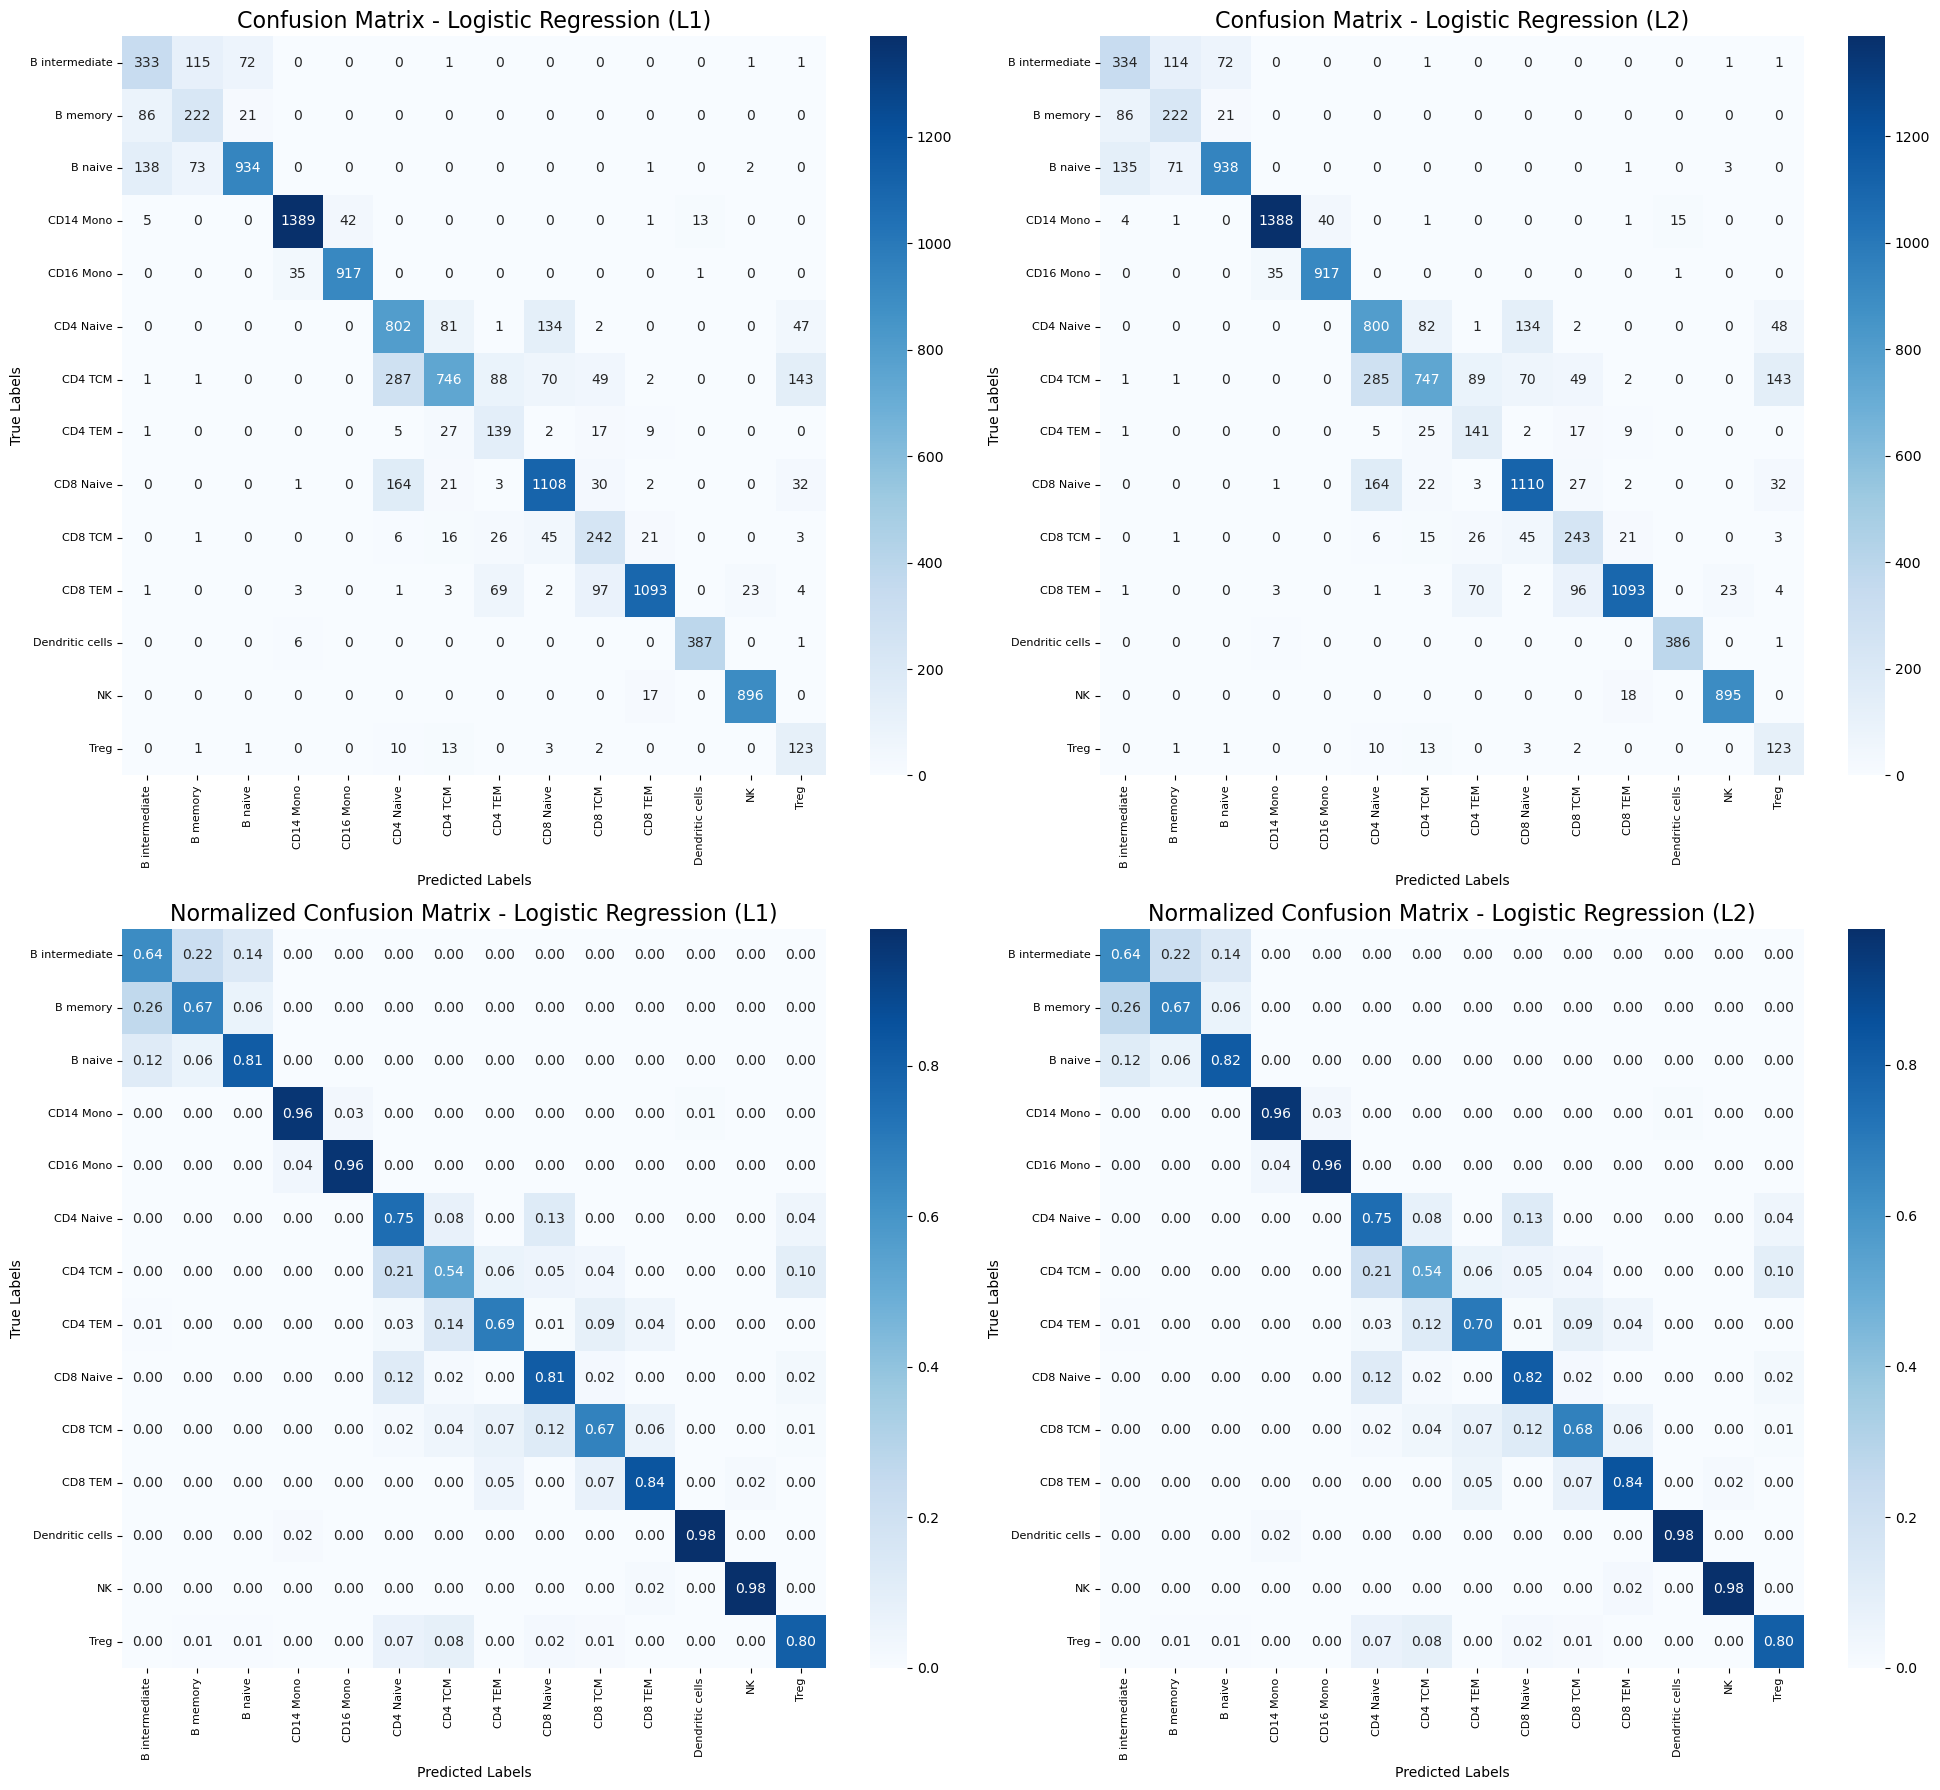

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(20, 18))

cm_l1 = confusion_matrix(y_val, y_val_pred_lr_l1)
sns.heatmap(cm_l1, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix - Logistic Regression (L1)", fontsize=16)
axes[0, 0].set_xlabel("Predicted Labels")
axes[0, 0].set_ylabel("True Labels")
axes[0, 0].tick_params(axis="x", rotation=90, labelsize=8)
axes[0, 0].tick_params(axis="y", labelsize=8)

cm_l2 = confusion_matrix(y_val, y_val_pred_lr_l2)
sns.heatmap(cm_l2, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[0, 1])
axes[0, 1].set_title("Confusion Matrix - Logistic Regression (L2)", fontsize=16)
axes[0, 1].set_xlabel("Predicted Labels")
axes[0, 1].set_ylabel("True Labels")
axes[0, 1].tick_params(axis="x", rotation=90, labelsize=8)
axes[0, 1].tick_params(axis="y", labelsize=8)

cm_normalized_l1 = cm_l1.astype("float") / cm_l1.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized_l1, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[1, 0])
axes[1, 0].set_title("Normalized Confusion Matrix - Logistic Regression (L1)", fontsize=16)
axes[1, 0].set_xlabel("Predicted Labels")
axes[1, 0].set_ylabel("True Labels")
axes[1, 0].tick_params(axis="x", rotation=90, labelsize=8)
axes[1, 0].tick_params(axis="y", labelsize=8)

cm_normalized_l2 = cm_l2.astype("float") / cm_l2.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized_l2, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[1, 1])
axes[1, 1].set_title("Normalized Confusion Matrix - Logistic Regression (L2)", fontsize=16)
axes[1, 1].set_xlabel("Predicted Labels")
axes[1, 1].set_ylabel("True Labels")
axes[1, 1].tick_params(axis="x", rotation=90, labelsize=8)
axes[1, 1].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "comparison_confusion_matrix_l1_l2.png"), dpi=300, bbox_inches="tight")
plt.show()

### ROC-AUC curves: L1 vs L2

In [67]:
# Rebuild what's needed (wiped by kernel restart)
y_val_bin = label_binarize(y_val, classes=np.unique(y_train))
n_classes = y_val_bin.shape[1]
color_palette = sns.color_palette("tab20", n_colors=min(20, n_classes))
color_palette += sns.color_palette("tab20b", n_colors=max(0, n_classes - 20))

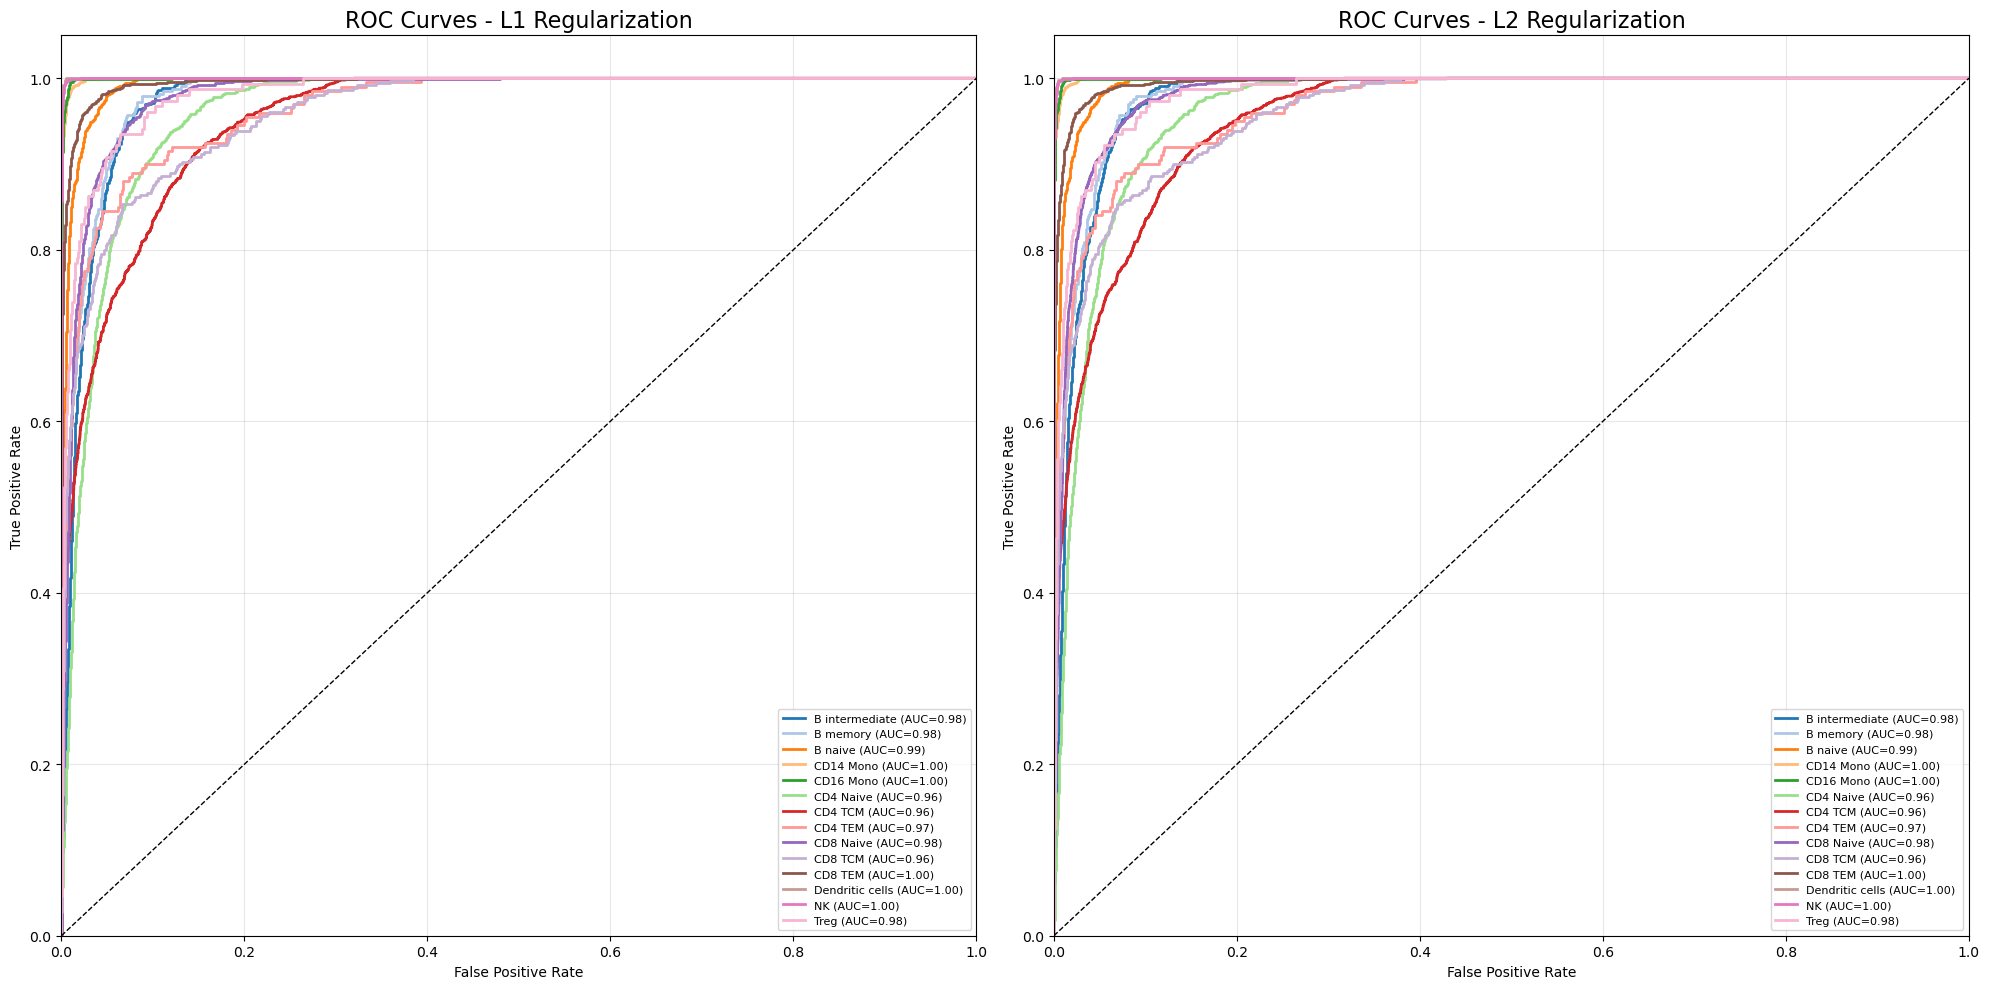

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for i in range(n_classes):
    fpr_l1, tpr_l1, _ = roc_curve(y_val_bin[:, i], y_val_proba_lr_l1[:, i])
    roc_auc_l1 = auc(fpr_l1, tpr_l1)
    class_name = label_encoder.classes_[i]
    axes[0].plot(fpr_l1, tpr_l1, lw=2, color=color_palette[i % len(color_palette)], label=f"{class_name} (AUC={roc_auc_l1:.2f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves - L1 Regularization", fontsize=16)
axes[0].legend(loc="lower right", fontsize=8)
axes[0].grid(alpha=0.3)

for i in range(n_classes):
    fpr_l2, tpr_l2, _ = roc_curve(y_val_bin[:, i], y_val_proba_lr_l2[:, i])
    roc_auc_l2 = auc(fpr_l2, tpr_l2)
    class_name = label_encoder.classes_[i]
    axes[1].plot(fpr_l2, tpr_l2, lw=2, color=color_palette[i % len(color_palette)], label=f"{class_name} (AUC={roc_auc_l2:.2f})")

axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves - L2 Regularization", fontsize=16)
axes[1].legend(loc="lower right", fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "comparison_roc_curves_l1_l2.png"), dpi=300, bbox_inches="tight")
plt.show()

### Precision-Recall curves: L1 vs L2

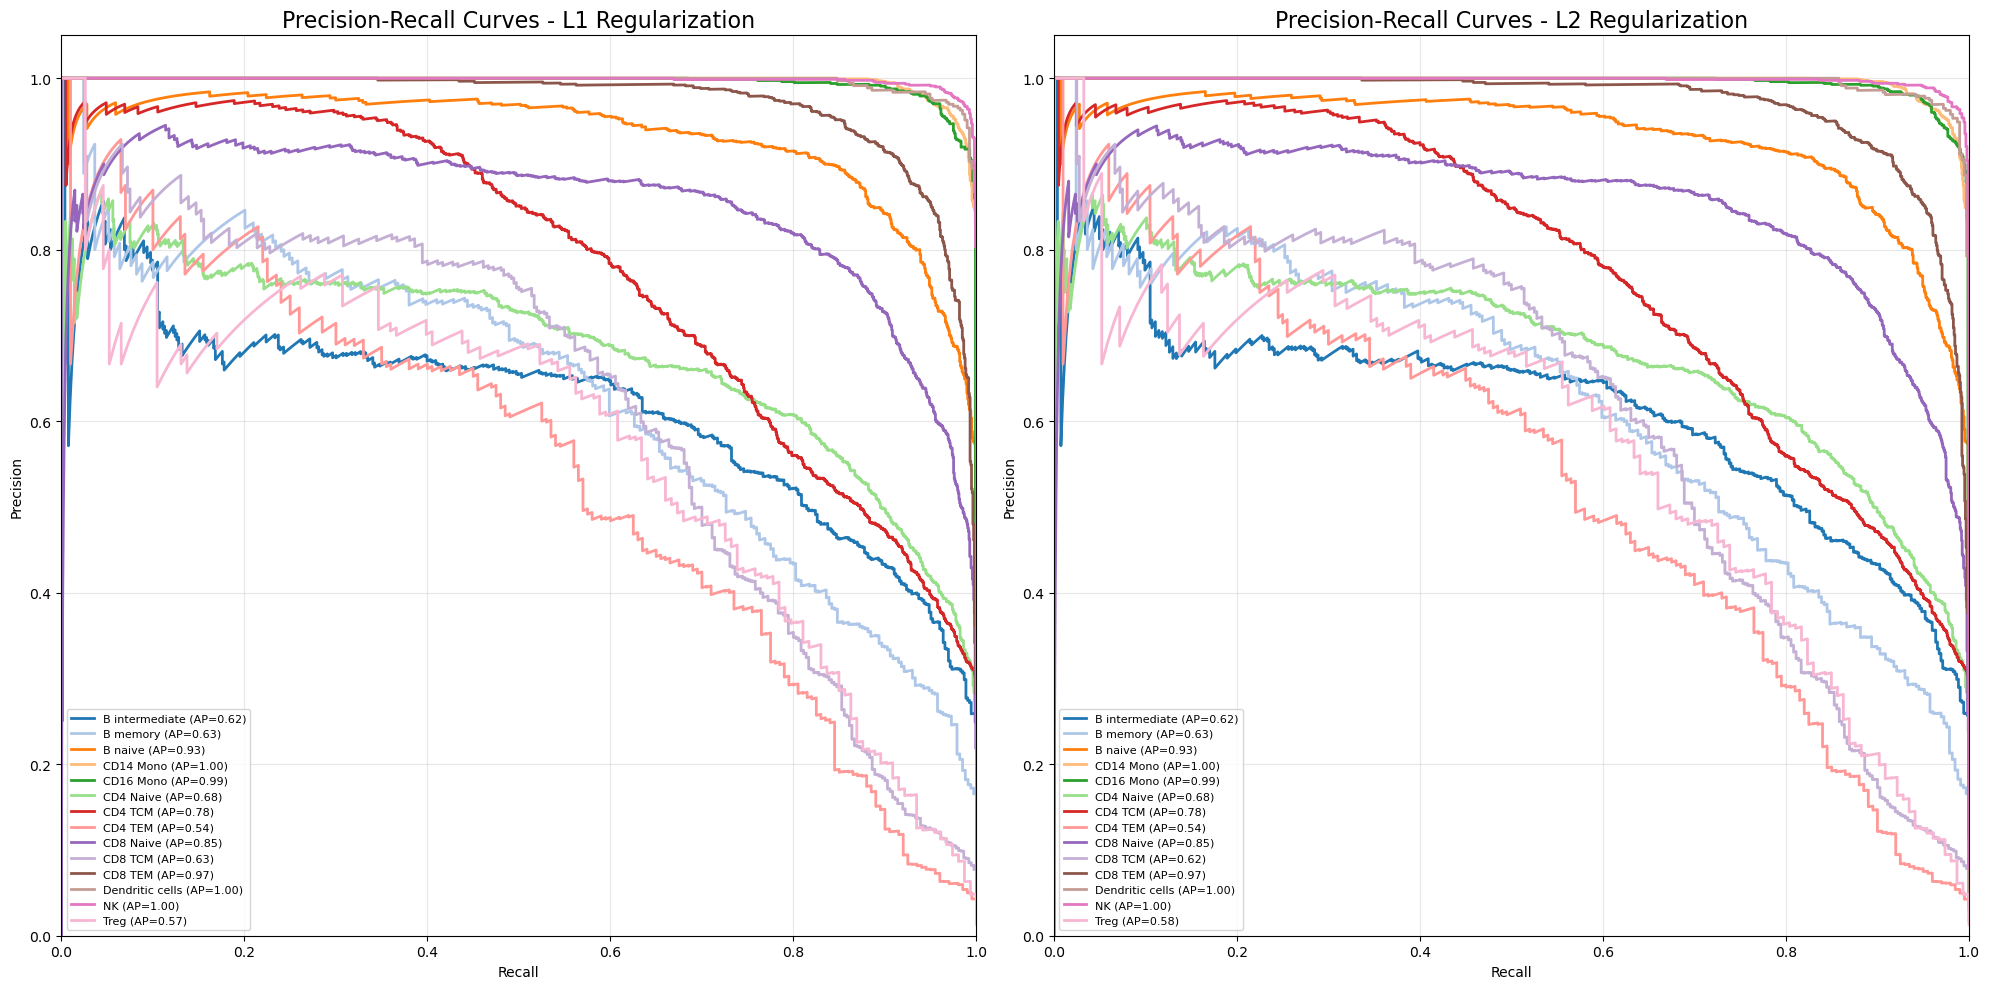

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_val_proba_lr_l1[:, i])
    pr_auc = average_precision_score(y_val_bin[:, i], y_val_proba_lr_l1[:, i])
    class_name = label_encoder.classes_[i]
    axes[0].plot(recall, precision, lw=2, color=color_palette[i % len(color_palette)], label=f"{class_name} (AP={pr_auc:.2f})")

axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curves - L1 Regularization", fontsize=16)
axes[0].legend(loc="best", fontsize=8)
axes[0].grid(alpha=0.3)

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_val_proba_lr_l2[:, i])
    pr_auc = average_precision_score(y_val_bin[:, i], y_val_proba_lr_l2[:, i])
    class_name = label_encoder.classes_[i]
    axes[1].plot(recall, precision, lw=2, color=color_palette[i % len(color_palette)], label=f"{class_name} (AP={pr_auc:.2f})")

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves - L2 Regularization", fontsize=16)
axes[1].legend(loc="best", fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "comparison_precision_recall_l1_l2.png"), dpi=300, bbox_inches="tight")
plt.show()

The confusion matrices, ROC curves, and precision-recall curves confirm the near-total equivalence between L1 and L2 regularization observed in the aggregate metrics. Cell counts in the confusion matrices differ by at most a handful of cells for any class pair, ROC AUC values match to two decimal places for every cell type, and precision-recall curves overlay almost exactly, with the largest visible difference being a 0.01 shift in CD8 TCM's average precision. The same error patterns identified for the Ridge Classifier persist here: CD4 TCM remains the most difficult class, splitting primarily between CD4 Naive and Treg, while the B cell subtypes retain their characteristic three way confusion. Regularization choice (L1 versus L2) has no meaningful impact on which cell types the model struggles with or why.

### Feature importance : L1 vs L2

In [70]:
l1_coef = np.abs(lr_l1_pipeline.named_steps["logistic"].coef_).mean(axis=0)
l2_coef = np.abs(lr_l2_pipeline.named_steps["logistic"].coef_).mean(axis=0)

feature_importance_comparison = pd.DataFrame({
    "Feature": feature_genes,
    "L1_Importance": l1_coef,
    "L2_Importance": l2_coef
})

feature_importance_comparison["Difference"] = feature_importance_comparison["L1_Importance"] - feature_importance_comparison["L2_Importance"]
feature_importance_comparison["Absolute_Diff"] = np.abs(feature_importance_comparison["Difference"])
feature_importance_comparison["Relative_Diff"] = feature_importance_comparison["Difference"] / feature_importance_comparison["L2_Importance"]

feature_importance_comparison = feature_importance_comparison.sort_values("Absolute_Diff", ascending=False)

print("Top 10 features with largest L1 vs L2 coefficient difference:")
print(feature_importance_comparison.head(10)[["Feature", "L1_Importance", "L2_Importance", "Difference"]])

Top 10 features with largest L1 vs L2 coefficient difference:
     Feature  L1_Importance  L2_Importance  Difference
7     S100A8       0.115593       0.272701   -0.157108
71  HLA-DRB5       0.218418       0.349111   -0.130694
3       CD74       0.324968       0.447937   -0.122969
63  SERPINA1       0.062370       0.184005   -0.121635
23  HLA-DPB1       0.329989       0.449743   -0.119755
12    TYROBP       0.217241       0.335437   -0.118196
51      FTH1       0.227600       0.334087   -0.106487
9       CCL5       0.788184       0.888620   -0.100436
17  HLA-DPA1       0.233935       0.333833   -0.099898
41      CYBB       0.138884       0.235080   -0.096196


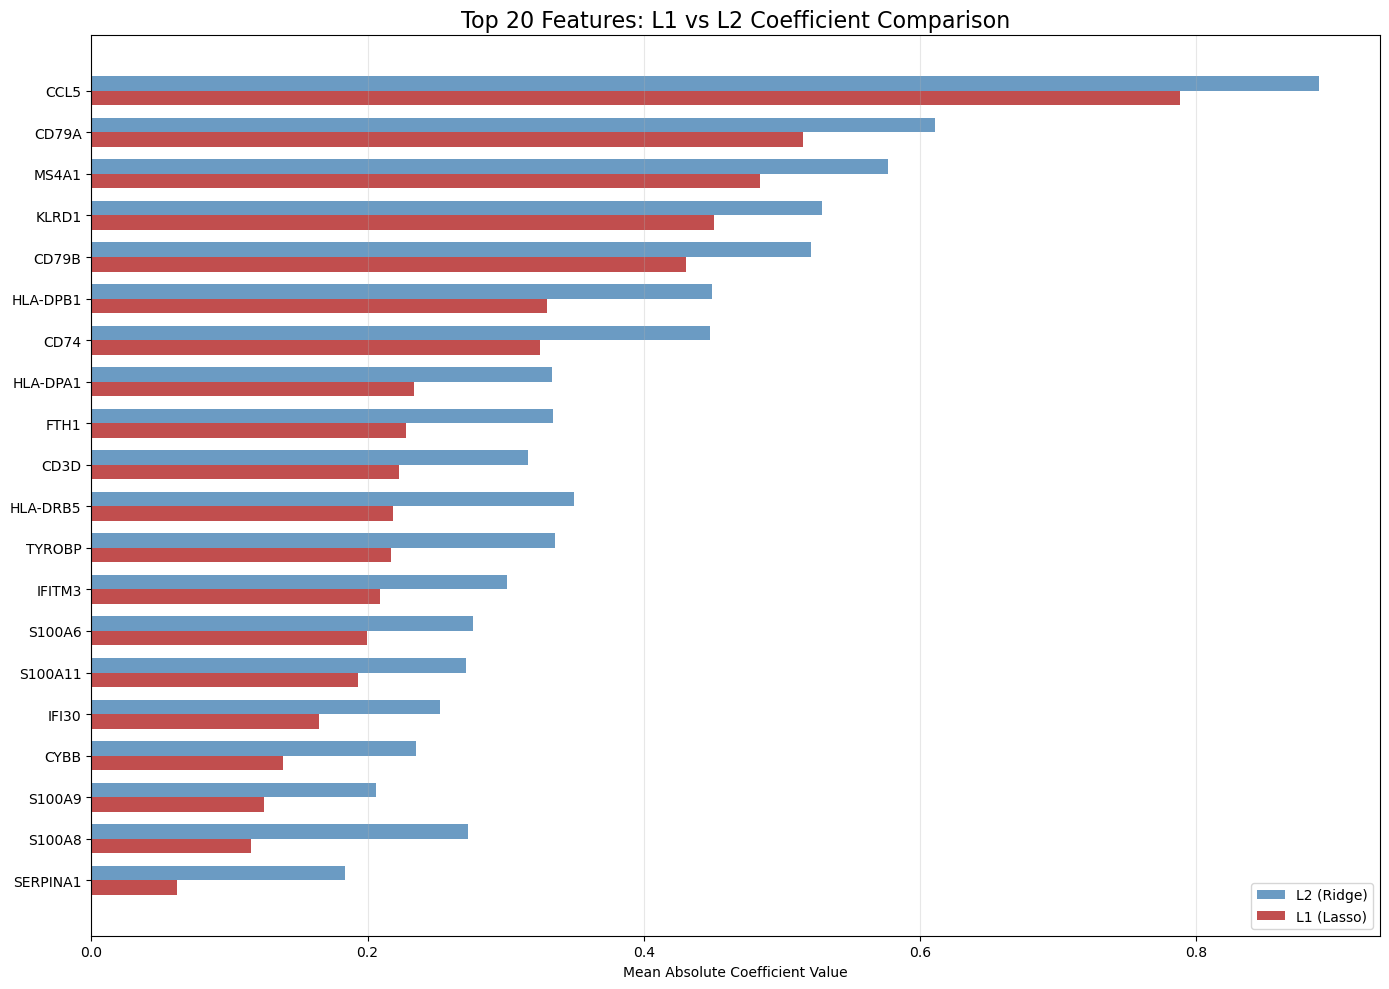

In [71]:
plt.figure(figsize=(14, 10))
comparison_plot = feature_importance_comparison.head(20).sort_values("L1_Importance", ascending=True)

indices = np.arange(len(comparison_plot))
width = 0.35

plt.barh(indices + width/2, comparison_plot["L2_Importance"], width, color="steelblue", alpha=0.8, label="L2 (Ridge)")
plt.barh(indices - width/2, comparison_plot["L1_Importance"], width, color="firebrick", alpha=0.8, label="L1 (Lasso)")

plt.yticks(indices, comparison_plot["Feature"])
plt.xlabel("Mean Absolute Coefficient Value")
plt.title("Top 20 Features: L1 vs L2 Coefficient Comparison", fontsize=16)
plt.legend(loc="lower right")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "comparison_feature_importance_l1_l2.png"), dpi=300, bbox_inches="tight")
plt.show()

### Confidence DIstributions : L1 vs L2

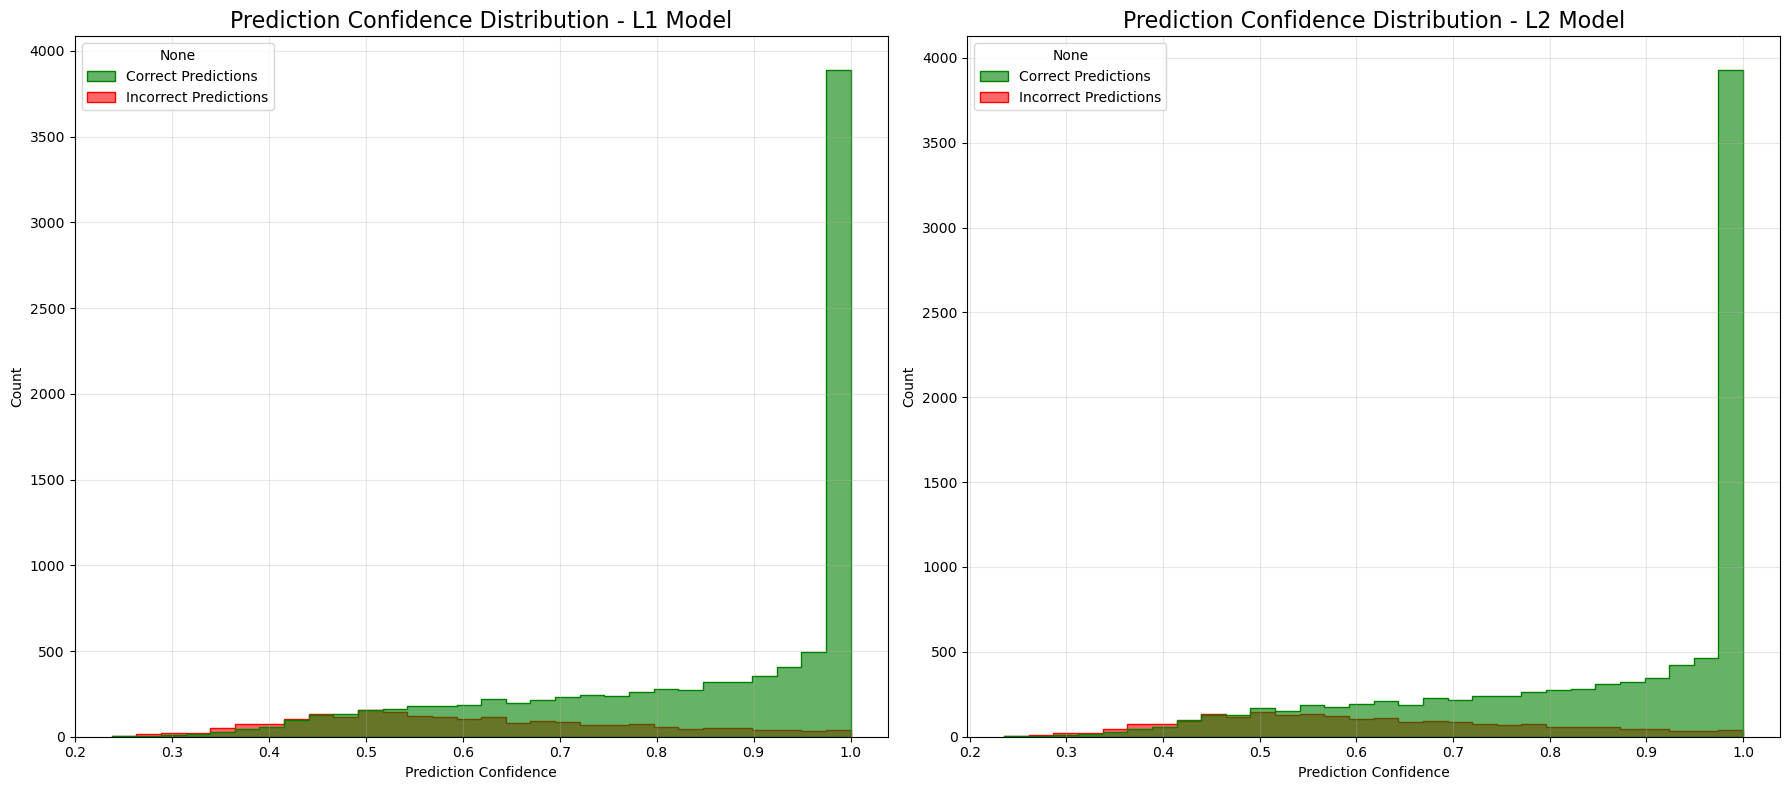

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

confidence_l1 = np.max(y_val_proba_lr_l1, axis=1)
confidence_l2 = np.max(y_val_proba_lr_l2, axis=1)

pred_status_l1 = pd.Series(y_val_pred_lr_l1 == y_val).map({True: "Correct Predictions", False: "Incorrect Predictions"})
pred_status_l2 = pd.Series(y_val_pred_lr_l2 == y_val).map({True: "Correct Predictions", False: "Incorrect Predictions"})

sns.histplot(
    x=confidence_l1, hue=pred_status_l1,
    bins=30, alpha=0.6, palette={"Correct Predictions": "green", "Incorrect Predictions": "red"},
    element="step", ax=axes[0]
)
axes[0].set_title("Prediction Confidence Distribution - L1 Model", fontsize=16)
axes[0].set_xlabel("Prediction Confidence")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.3)

sns.histplot(
    x=confidence_l2, hue=pred_status_l2,
    bins=30, alpha=0.6, palette={"Correct Predictions": "green", "Incorrect Predictions": "red"},
    element="step", ax=axes[1]
)
axes[1].set_title("Prediction Confidence Distribution - L2 Model", fontsize=16)
axes[1].set_xlabel("Prediction Confidence")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "comparison_confidence_l1_l2.png"), dpi=300, bbox_inches="tight")
plt.show()

### UMAP misclassification analysis : L1 vs L2

In [74]:
# Recompute UMAP embedding (needed since kernel restart wiped it)
print("Generating UMAP embedding for L1/L2 misclassification visualization...")
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.3, random_state=RAND_SEED)
X_val_umap = reducer.fit_transform(X_val)

Generating UMAP embedding for L1/L2 misclassification visualization...


/home/rajan/miniforge3/envs/immune_ml_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


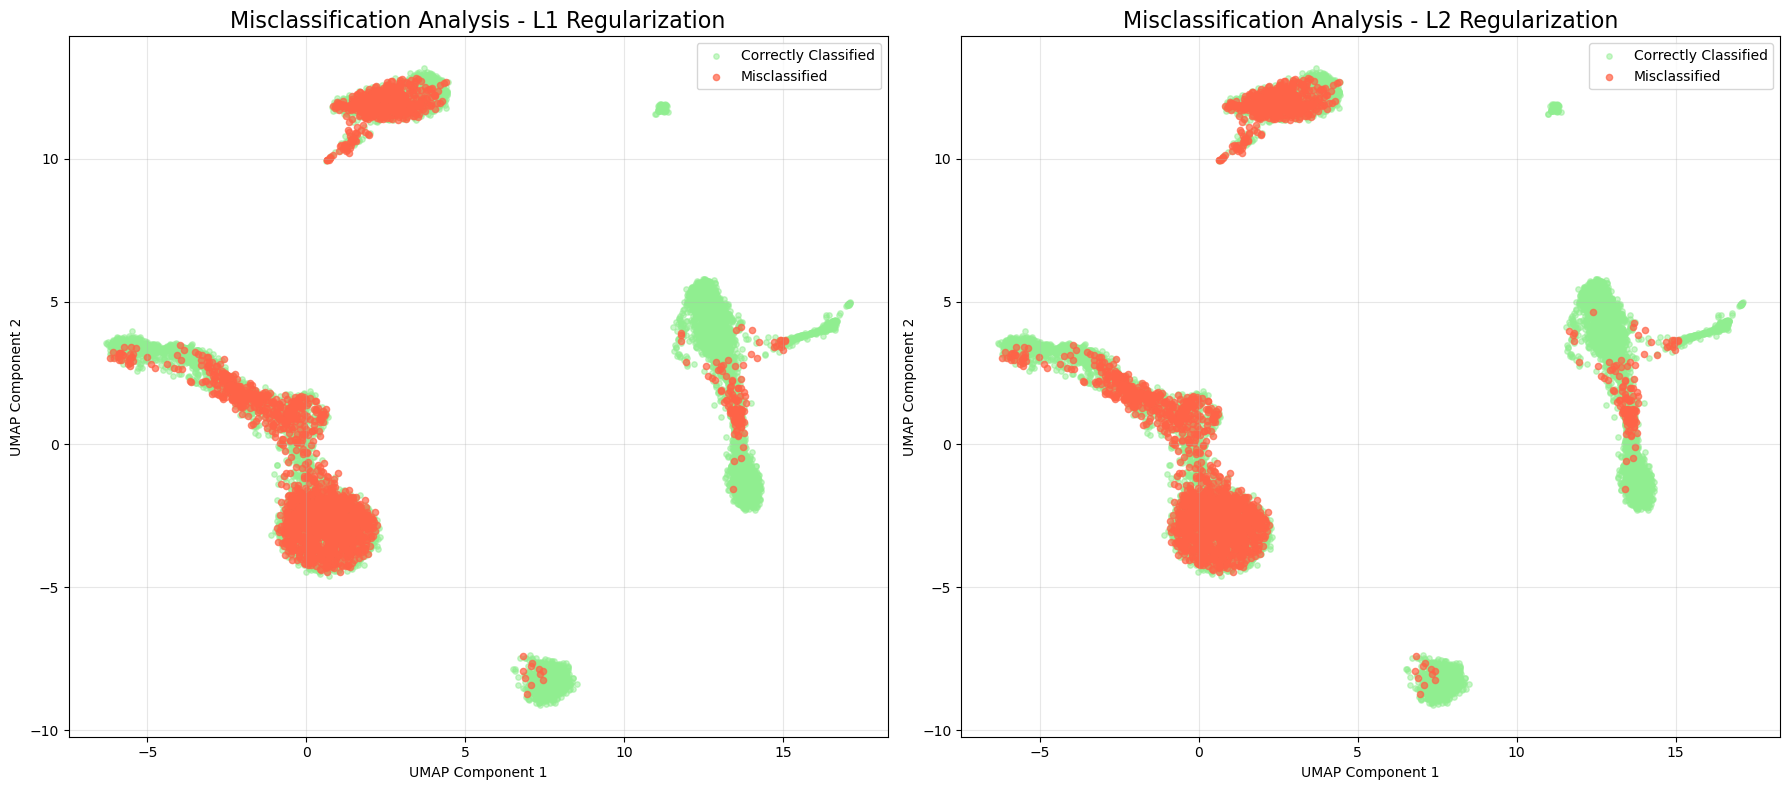

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

correct_mask_l1 = (y_val_pred_lr_l1 == y_val)
axes[0].scatter(X_val_umap[correct_mask_l1, 0], X_val_umap[correct_mask_l1, 1], c="lightgreen", s=15, alpha=0.5, label="Correctly Classified")
axes[0].scatter(X_val_umap[~correct_mask_l1, 0], X_val_umap[~correct_mask_l1, 1], c="tomato", s=20, alpha=0.7, label="Misclassified")
axes[0].set_title("Misclassification Analysis - L1 Regularization", fontsize=16)
axes[0].set_xlabel("UMAP Component 1")
axes[0].set_ylabel("UMAP Component 2")
axes[0].legend(loc="best")
axes[0].grid(alpha=0.3)

correct_mask_l2 = (y_val_pred_lr_l2 == y_val)
axes[1].scatter(X_val_umap[correct_mask_l2, 0], X_val_umap[correct_mask_l2, 1], c="lightgreen", s=15, alpha=0.5, label="Correctly Classified")
axes[1].scatter(X_val_umap[~correct_mask_l2, 0], X_val_umap[~correct_mask_l2, 1], c="tomato", s=20, alpha=0.7, label="Misclassified")
axes[1].set_title("Misclassification Analysis - L2 Regularization", fontsize=16)
axes[1].set_xlabel("UMAP Component 1")
axes[1].set_ylabel("UMAP Component 2")
axes[1].legend(loc="best")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "comparison_misclassification_umap_l1_l2.png"), dpi=300, bbox_inches="tight")
plt.show()


### Performance metric bar chart analysis : L1 vs L2

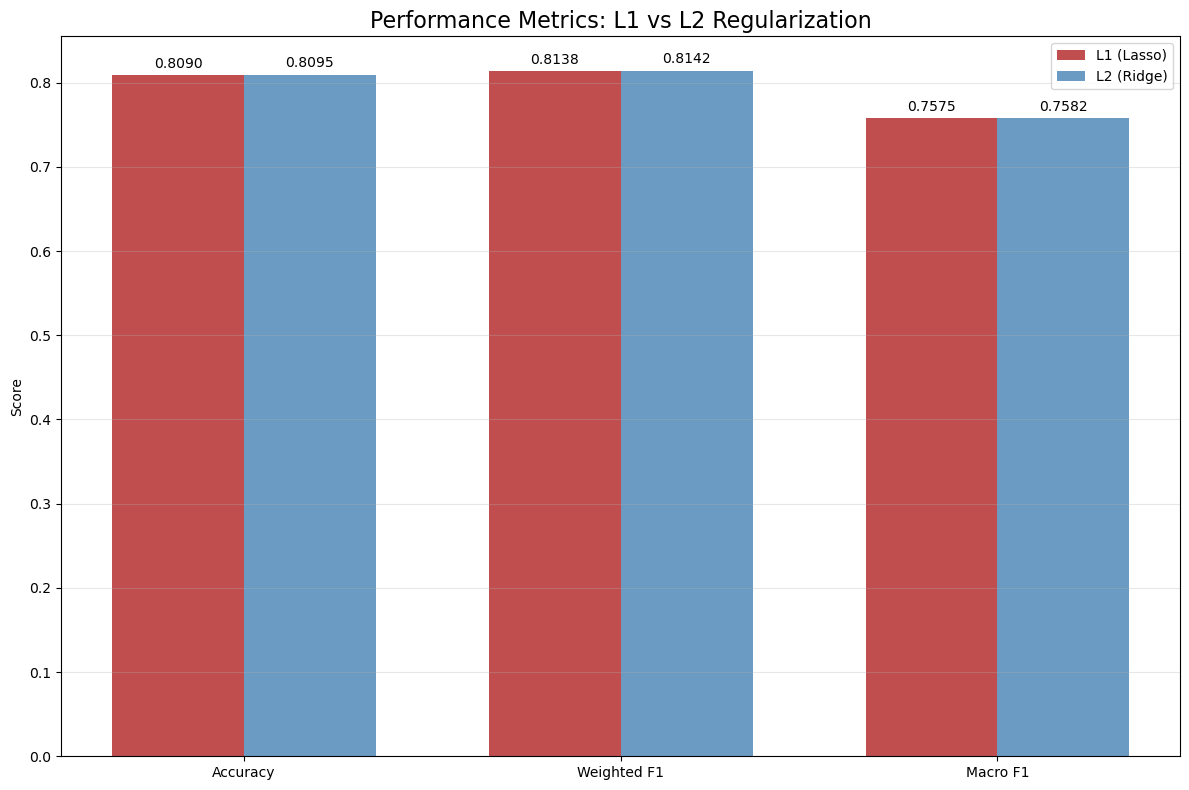

In [76]:
metrics = ["Accuracy", "Weighted F1", "Macro F1"]
l1_values = [accuracy_l1, weighted_f1_l1, macro_f1_l1]
l2_values = [accuracy_l2, weighted_f1_l2, macro_f1_l2]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 8))
rects1 = ax.bar(x - width/2, l1_values, width, label="L1 (Lasso)", color="firebrick", alpha=0.8)
rects2 = ax.bar(x + width/2, l2_values, width, label="L2 (Ridge)", color="steelblue", alpha=0.8)

ax.set_ylabel("Score")
ax.set_title("Performance Metrics: L1 vs L2 Regularization", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f"{height:.4f}", xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha="center", va="bottom")

autolabel(rects1)
autolabel(rects2)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "comparison_performance_metrics_l1_l2.png"), dpi=300, bbox_inches="tight")
plt.show()

In [78]:
l1_coefficients_raw = lr_l1_pipeline.named_steps["logistic"].coef_
l2_coefficients_raw = lr_l2_pipeline.named_steps["logistic"].coef_

l1_sparsity = np.mean(l1_coefficients_raw == 0) * 100
l2_sparsity = np.mean(l2_coefficients_raw == 0) * 100

zero_coeffs_l1 = int(np.sum(l1_coefficients_raw == 0))
total_coeffs_l1 = l1_coefficients_raw.size
nonzero_coeffs_l1 = total_coeffs_l1 - zero_coeffs_l1

print("\nComparative Performance Analysis: L1 vs L2 Regularization")
print("=" * 80)
print(f"{'Metric':<25}{'L1 (Lasso)':<15}{'L2 (Ridge)':<15}{'Difference':<15}")
print("-" * 80)
print(f"{'Accuracy':<25}{accuracy_l1:.6f}{'':<7}{accuracy_l2:.6f}{'':<7}{(accuracy_l1-accuracy_l2):.6f}")
print(f"{'Weighted F1-Score':<25}{weighted_f1_l1:.6f}{'':<7}{weighted_f1_l2:.6f}{'':<7}{(weighted_f1_l1-weighted_f1_l2):.6f}")
print(f"{'Macro F1-Score':<25}{macro_f1_l1:.6f}{'':<7}{macro_f1_l2:.6f}{'':<7}{(macro_f1_l1-macro_f1_l2):.6f}")
print(f"{'Coefficient Sparsity':<25}{l1_sparsity:.2f}%{'':<7}{l2_sparsity:.2f}%{'':<7}{(l1_sparsity-l2_sparsity):.2f}%")
print(f"{'Zero Coefficients':<25}{zero_coeffs_l1}/{total_coeffs_l1}{'':<7}{'0/1400'}")
print("=" * 80)


Comparative Performance Analysis: L1 vs L2 Regularization
Metric                   L1 (Lasso)     L2 (Ridge)     Difference     
--------------------------------------------------------------------------------
Accuracy                 0.808999       0.809520       -0.000520
Weighted F1-Score        0.813764       0.814242       -0.000478
Macro F1-Score           0.757459       0.758222       -0.000763
Coefficient Sparsity     12.14%       0.00%       12.14%
Zero Coefficients        170/1400       0/1400


### Logistic Regression: L1 vs L2 Comparison

L1 and L2 regularization produce statistically indistinguishable predictive performance on this dataset. Accuracy differs by only 0.0005 (0.8090 versus 0.8095), weighted F1 by 0.0005, and macro F1 by 0.0008. No cell type shows a meaningfully different F1 score between the two models, and the confusion matrices, ROC curves, and precision-recall curves are visually near-identical across all fourteen classes. Both models reproduce the same error patterns observed for the Ridge Classifier: CD4 TCM remains the most difficult class, splitting primarily into CD4 Naive and Treg, while the B cell subtypes retain a consistent three way confusion pattern.

The two penalties diverge sharply, however, in coefficient sparsity. L1 sets 170 of 1400 total coefficients (12.14%) to exactly zero, while L2 produces no zero coefficients (0.00%), confirming the expected theoretical distinction in practice: L1's non-smooth penalty at zero induces genuine sparsity and implicit feature selection, while L2's smooth penalty shrinks coefficient magnitudes without eliminating them. This sparsity difference is also visible in the averaged feature importance comparison, where L2 shows consistently higher mean absolute coefficients than L1 across nearly every top gene, a direct consequence of L1 zeroing out a subset of class specific coefficients that L2 retains at reduced but nonzero magnitude.

Prediction confidence distributions and UMAP misclassification patterns are visually indistinguishable between the two models, both showing the characteristic concentration of correct, high confidence predictions and misclassified, lower confidence predictions within the same lower left region of transcriptionally similar T cell and B cell subtypes.

Given the equivalent predictive performance, L1's sparsity offers a mild interpretability advantage at no accuracy cost, since roughly one in eight gene-class coefficient pairs is identified as uninformative and removed entirely from the fitted model. Both models remain substantially better calibrated for well separated lineages (NK, CD14 Mono, CD16 Mono, Dendritic cells) than for transcriptionally overlapping T cell and B cell subtypes.

### UMAP visualization of Logistic regression classifier predictions and cluster analysis

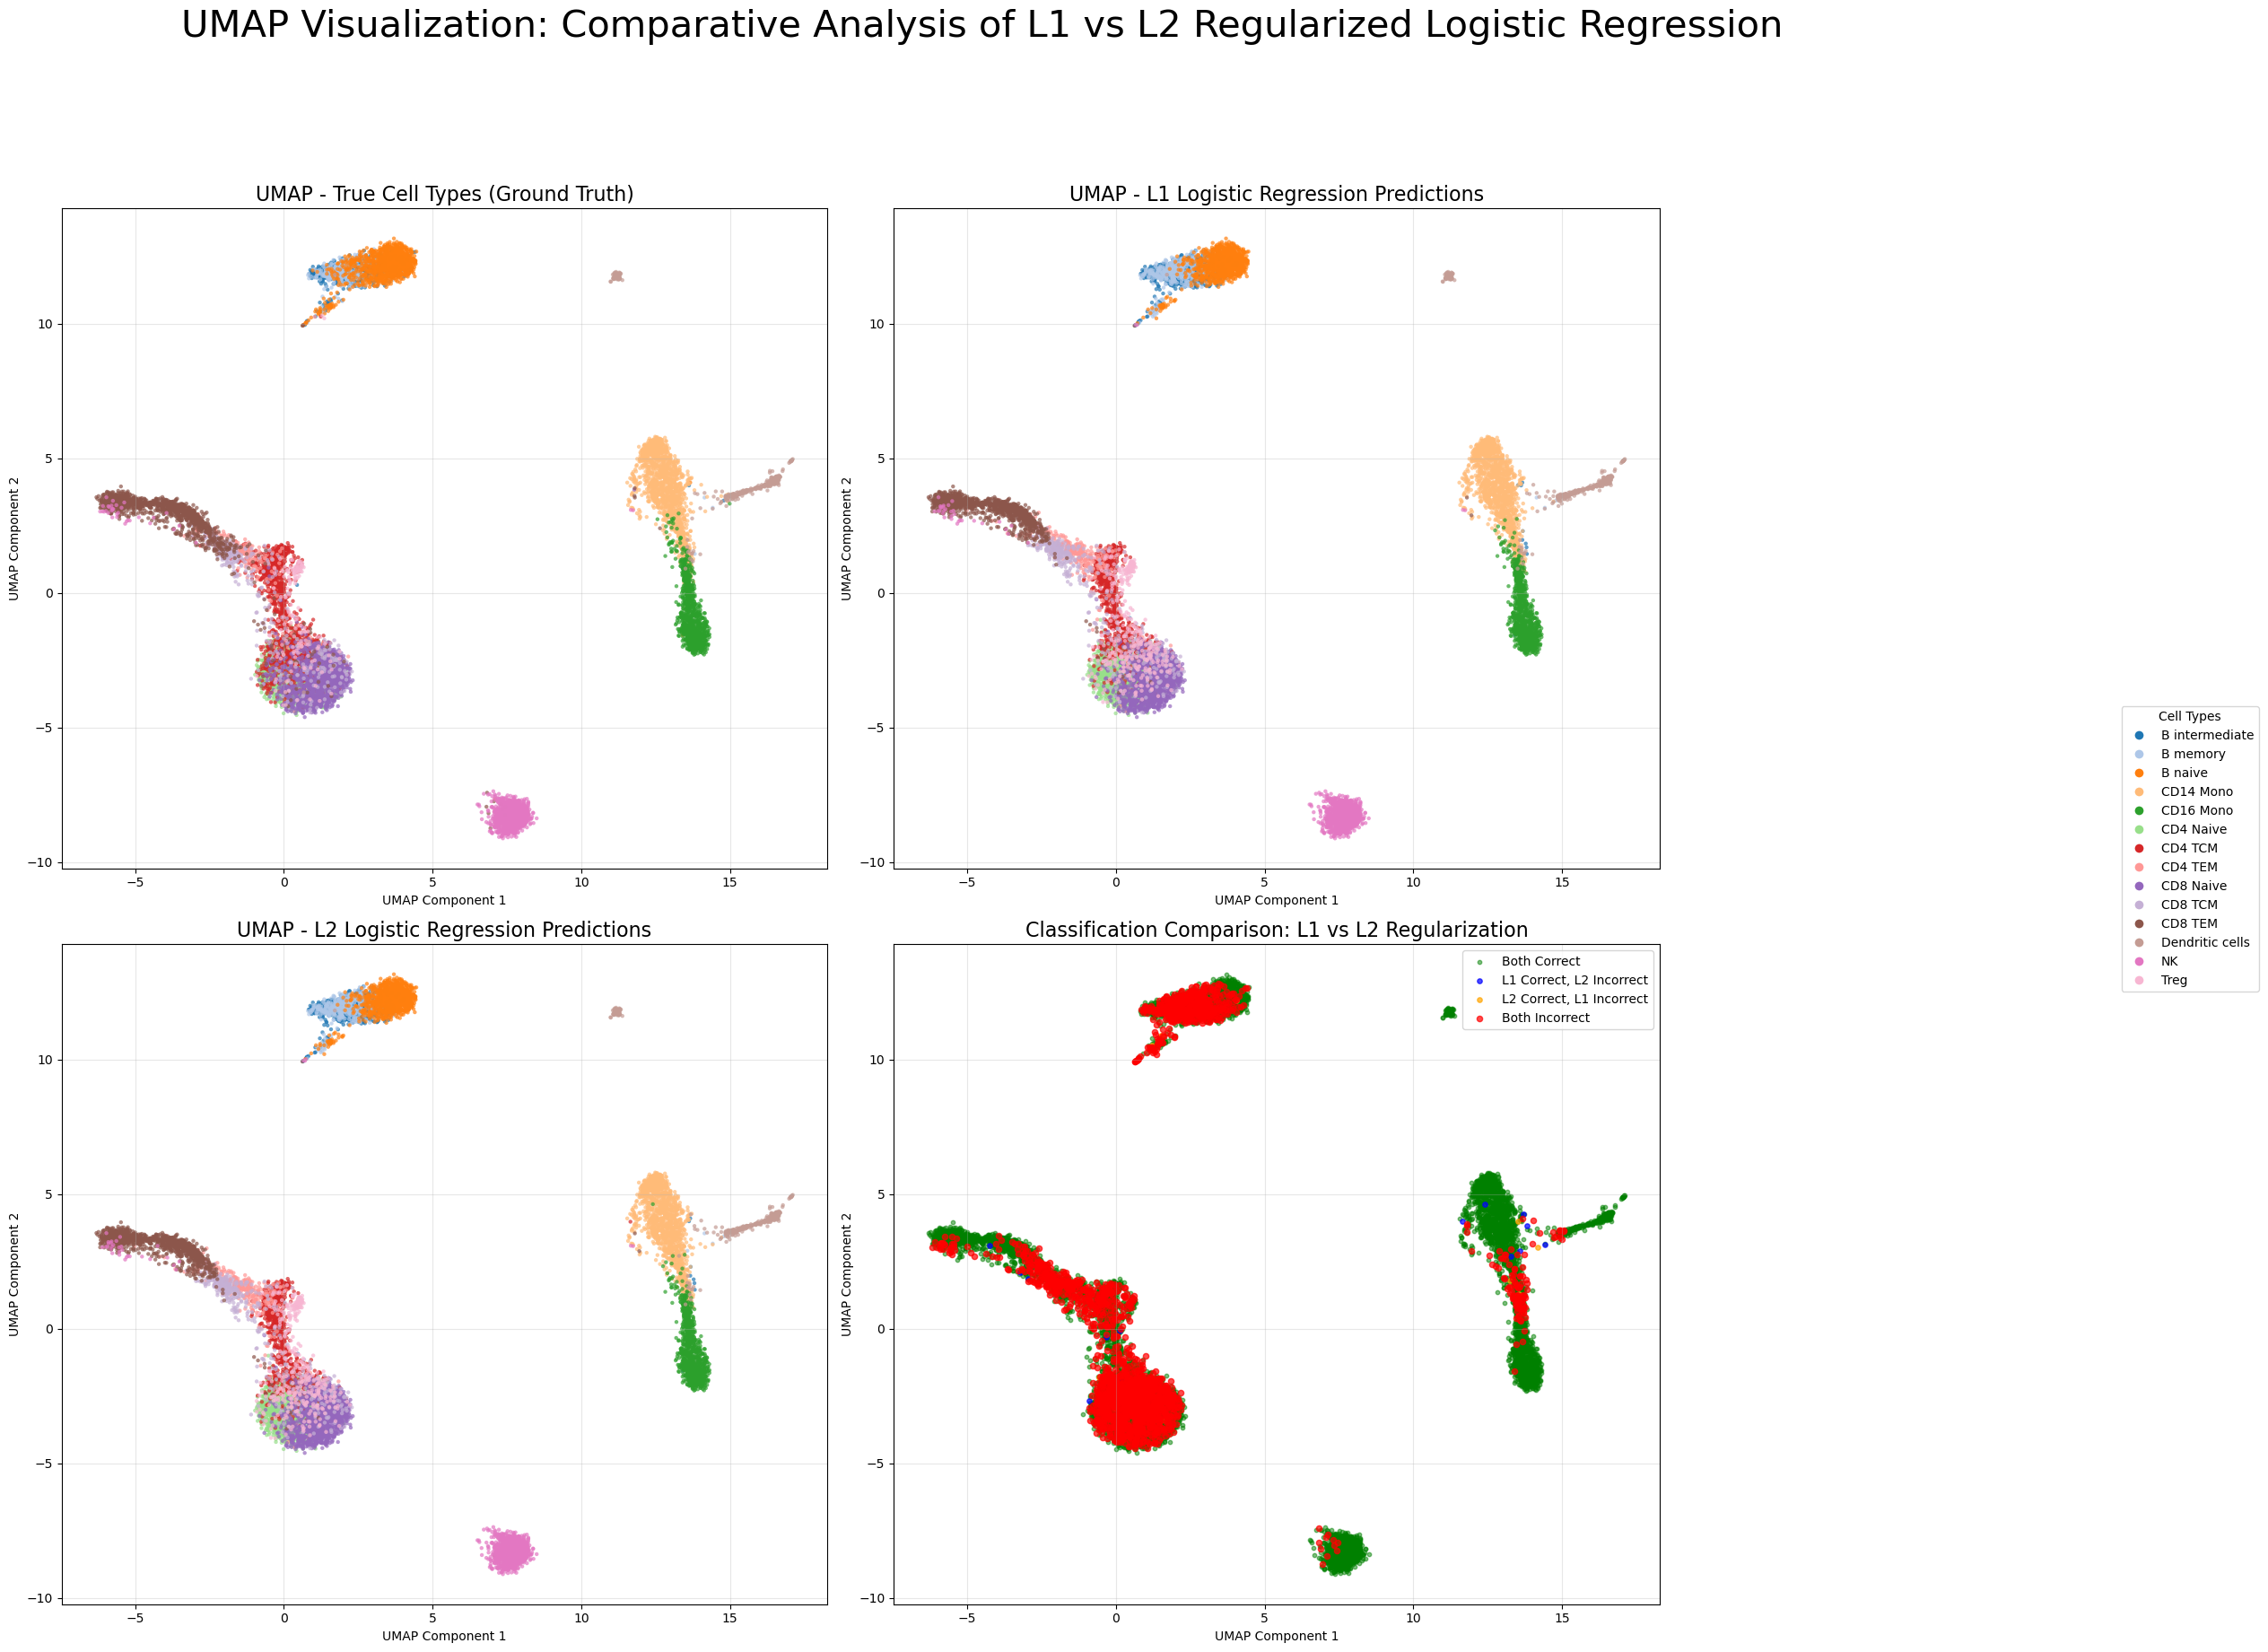

In [81]:
if "X_val_umap" not in locals():
    print("Generating UMAP embedding for visualization...")
    reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.3, random_state=RAND_SEED)
    X_val_umap = reducer.fit_transform(X_val)

fig, axes = plt.subplots(2, 2, figsize=(22, 18))

unique_cell_types = np.unique(meta_val["CellType"])
n_colors = len(unique_cell_types)
color_palette = sns.color_palette("tab20", n_colors=min(20, n_colors))
color_palette += sns.color_palette("tab20b", n_colors=max(0, n_colors - 20))
color_dict = {cell_type: color_palette[i % len(color_palette)] for i, cell_type in enumerate(unique_cell_types)}

for cell_type in unique_cell_types:
    mask = (meta_val["CellType"] == cell_type)
    axes[0, 0].scatter(X_val_umap[mask, 0], 
                       X_val_umap[mask, 1], 
                       s=10, color=color_dict[cell_type], 
                       alpha=0.7, 
                       edgecolor="none")
axes[0, 0].set_title("UMAP - True Cell Types (Ground Truth)", fontsize=16)
axes[0, 0].set_xlabel("UMAP Component 1")
axes[0, 0].set_ylabel("UMAP Component 2")
axes[0, 0].grid(alpha=0.3)

predicted_cell_types_l1 = label_encoder.inverse_transform(y_val_pred_lr_l1)
for cell_type in unique_cell_types:
    mask = (predicted_cell_types_l1 == cell_type)
    axes[0, 1].scatter(X_val_umap[mask, 0], 
                       X_val_umap[mask, 1], 
                       s=10, 
                       color=color_dict[cell_type], 
                       alpha=0.7, 
                       edgecolor="none")
axes[0, 1].set_title("UMAP - L1 Logistic Regression Predictions", fontsize=16)
axes[0, 1].set_xlabel("UMAP Component 1")
axes[0, 1].set_ylabel("UMAP Component 2")
axes[0, 1].grid(alpha=0.3)

predicted_cell_types_l2 = label_encoder.inverse_transform(y_val_pred_lr_l2)
for cell_type in unique_cell_types:
    mask = (predicted_cell_types_l2 == cell_type)
    axes[1, 0].scatter(X_val_umap[mask, 0], 
                       X_val_umap[mask, 1], 
                       s=10, 
                       color=color_dict[cell_type], 
                       alpha=0.7, 
                       edgecolor="none")
axes[1, 0].set_title("UMAP - L2 Logistic Regression Predictions", fontsize=16)
axes[1, 0].set_xlabel("UMAP Component 1")
axes[1, 0].set_ylabel("UMAP Component 2")
axes[1, 0].grid(alpha=0.3)

correct_mask_l1 = (y_val_pred_lr_l1 == y_val)
correct_mask_l2 = (y_val_pred_lr_l2 == y_val)

both_correct = correct_mask_l1 & correct_mask_l2
l1_only_correct = correct_mask_l1 & ~correct_mask_l2
l2_only_correct = ~correct_mask_l1 & correct_mask_l2
both_incorrect = ~correct_mask_l1 & ~correct_mask_l2

axes[1, 1].scatter(X_val_umap[both_correct, 0], X_val_umap[both_correct, 1], s=10, color="green", alpha=0.5, label="Both Correct")
axes[1, 1].scatter(X_val_umap[l1_only_correct, 0], X_val_umap[l1_only_correct, 1], s=15, color="blue", alpha=0.7, label="L1 Correct, L2 Incorrect")
axes[1, 1].scatter(X_val_umap[l2_only_correct, 0], X_val_umap[l2_only_correct, 1], s=15, color="orange", alpha=0.7, label="L2 Correct, L1 Incorrect")
axes[1, 1].scatter(X_val_umap[both_incorrect, 0], X_val_umap[both_incorrect, 1], s=20, color="red", alpha=0.7, label="Both Incorrect")
axes[1, 1].set_title("Classification Comparison: L1 vs L2 Regularization", fontsize=16)
axes[1, 1].set_xlabel("UMAP Component 1")
axes[1, 1].set_ylabel("UMAP Component 2")
axes[1, 1].legend(fontsize=10, loc="upper right")
axes[1, 1].grid(alpha=0.3)

handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color_dict[ct], markersize=8) for ct in unique_cell_types]
fig.legend(handles, unique_cell_types, loc="center right", title="Cell Types", bbox_to_anchor=(1.15, 0.5), fontsize=10)

plt.suptitle("UMAP Visualization: Comparative Analysis of L1 vs L2 Regularized Logistic Regression", fontsize=30, y=1.02)
plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.savefig(os.path.join(PLOT_DIR, "umap_l1_l2_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

In [82]:
# Classification agreement statistics
total_cells = len(y_val)
both_correct_count = np.sum(both_correct)
l1_only_correct_count = np.sum(l1_only_correct)
l2_only_correct_count = np.sum(l2_only_correct)
both_incorrect_count = np.sum(both_incorrect)

print("=== UMAP Classification Analysis: L1 vs L2 Regularization ===")
print(f"Total validation cells: {total_cells}")
print(f"Both models correct: {both_correct_count} ({100*both_correct_count/total_cells:.2f}%)")
print(f"L1 correct but L2 incorrect: {l1_only_correct_count} ({100*l1_only_correct_count/total_cells:.2f}%)")
print(f"L2 correct but L1 incorrect: {l2_only_correct_count} ({100*l2_only_correct_count/total_cells:.2f}%)")
print(f"Both models incorrect: {both_incorrect_count} ({100*both_incorrect_count/total_cells:.2f}%)")

=== UMAP Classification Analysis: L1 vs L2 Regularization ===
Total validation cells: 11534
Both models correct: 9314 (80.75%)
L1 correct but L2 incorrect: 17 (0.15%)
L2 correct but L1 incorrect: 23 (0.20%)
Both models incorrect: 2180 (18.90%)


In [83]:
# Cell-type-specific disagreement rates
disagreement_mask = l1_only_correct | l2_only_correct

disagreement_types = meta_val.loc[disagreement_mask, "CellType"].value_counts()
total_types = meta_val["CellType"].value_counts()

disagreement_rates = {ct: disagreement_types.get(ct, 0) / total_types[ct] for ct in unique_cell_types}

print("Cell types by model disagreement rate (highest first):")
for cell_type, rate in sorted(disagreement_rates.items(), key=lambda x: -x[1]):
    count = disagreement_types.get(cell_type, 0)
    total = total_types[cell_type]
    print(f"{cell_type}: {count}/{total} cells ({rate*100:.2f}%) show model disagreement")

Cell types by model disagreement rate (highest first):
CD4 TEM: 2/200 cells (1.00%) show model disagreement
CD14 Mono: 11/1450 cells (0.76%) show model disagreement
CD4 TCM: 7/1387 cells (0.50%) show model disagreement
CD4 Naive: 4/1067 cells (0.37%) show model disagreement
B naive: 4/1148 cells (0.35%) show model disagreement
CD8 TEM: 4/1296 cells (0.31%) show model disagreement
CD8 Naive: 4/1361 cells (0.29%) show model disagreement
CD8 TCM: 1/360 cells (0.28%) show model disagreement
Dendritic cells: 1/394 cells (0.25%) show model disagreement
B intermediate: 1/523 cells (0.19%) show model disagreement
NK: 1/913 cells (0.11%) show model disagreement
B memory: 0/329 cells (0.00%) show model disagreement
CD16 Mono: 0/953 cells (0.00%) show model disagreement
Treg: 0/153 cells (0.00%) show model disagreement


The UMAP comparison and disagreement analysis quantify just how similar L1 and L2 regularization are in practice. Of 11,534 validation cells, 80.75% are correctly classified by both models and 18.90% are misclassified by both models identically, meaning the two models fail on essentially the same cells rather than different ones. Only 40 cells total (0.35%) show any disagreement between the two models, split nearly evenly between L1-only-correct (17 cells) and L2-only-correct (23 cells). Per cell type, disagreement rates are uniformly small, with the highest at 1.00% (CD4 TEM) and three cell types (B memory, CD16 Mono, Treg) showing zero disagreement whatsoever. This strongly suggests that regularization type is not the limiting factor for this dataset. The 18.90% shared error rate reflects intrinsic ambiguity in transcriptionally similar cell types (primarily CD4 TCM, the T cell memory and naive subsets, and the B cell subtypes) rather than a property either penalty could meaningfully resolve.

### Per class accuracy comparisons: L1 vs L2

In [84]:
l1_better_types = []
l2_better_types = []
tie_types = []

for cell_type in unique_cell_types:
    cell_type_indices = np.where(meta_val["CellType"] == cell_type)[0]
    l1_accuracy = np.mean(correct_mask_l1[cell_type_indices])
    l2_accuracy = np.mean(correct_mask_l2[cell_type_indices])
    diff = l1_accuracy - l2_accuracy

    if diff > 0.01:
        l1_better_types.append((cell_type, l1_accuracy, l2_accuracy, diff, len(cell_type_indices)))
    elif diff < -0.01:
        l2_better_types.append((cell_type, l1_accuracy, l2_accuracy, diff, len(cell_type_indices)))
    else:
        tie_types.append((cell_type, l1_accuracy, l2_accuracy, diff, len(cell_type_indices)))

print("=== Cell Type-Specific Performance Analysis ===")

if l1_better_types:
    print("\nCell types where L1 performs better:")
    for cell_type, l1_acc, l2_acc, diff, count in sorted(l1_better_types, key=lambda x: -x[3]):
        print(f"{cell_type}: L1={l1_acc:.4f}, L2={l2_acc:.4f}, Diff={diff:.4f}, Count={count}")

if l2_better_types:
    print("\nCell types where L2 performs better:")
    for cell_type, l1_acc, l2_acc, diff, count in sorted(l2_better_types, key=lambda x: x[3]):
        print(f"{cell_type}: L1={l1_acc:.4f}, L2={l2_acc:.4f}, Diff={diff:.4f}, Count={count}")

if tie_types:
    print(f"\nCell types with similar performance ({len(tie_types)} of {len(unique_cell_types)}):")
    for cell_type, l1_acc, l2_acc, diff, count in sorted(tie_types, key=lambda x: -abs(x[3])):
        print(f"{cell_type}: L1={l1_acc:.4f}, L2={l2_acc:.4f}, Diff={diff:.4f}, Count={count}")

=== Cell Type-Specific Performance Analysis ===

Cell types where L2 performs better:
CD4 TEM: L1=0.6950, L2=0.7050, Diff=-0.0100, Count=200

Cell types with similar performance (13 of 14):
B naive: L1=0.8136, L2=0.8171, Diff=-0.0035, Count=1148
CD8 TCM: L1=0.6722, L2=0.6750, Diff=-0.0028, Count=360
Dendritic cells: L1=0.9822, L2=0.9797, Diff=0.0025, Count=394
B intermediate: L1=0.6367, L2=0.6386, Diff=-0.0019, Count=523
CD4 Naive: L1=0.7516, L2=0.7498, Diff=0.0019, Count=1067
CD8 Naive: L1=0.8141, L2=0.8156, Diff=-0.0015, Count=1361
NK: L1=0.9814, L2=0.9803, Diff=0.0011, Count=913
CD4 TCM: L1=0.5379, L2=0.5386, Diff=-0.0007, Count=1387
CD14 Mono: L1=0.9579, L2=0.9572, Diff=0.0007, Count=1450
B memory: L1=0.6748, L2=0.6748, Diff=0.0000, Count=329
CD16 Mono: L1=0.9622, L2=0.9622, Diff=0.0000, Count=953
CD8 TEM: L1=0.8434, L2=0.8434, Diff=0.0000, Count=1296
Treg: L1=0.8039, L2=0.8039, Diff=0.0000, Count=153


### Top misclassification pairs per model

In [86]:
cell_types_numeric = label_encoder.transform(unique_cell_types)

def top_misclass_pairs(y_true, y_pred, n=5):
    pairs = []
    for true_idx in cell_types_numeric:
        for pred_idx in cell_types_numeric:
            if true_idx != pred_idx:
                count = np.sum((y_true == true_idx) & (y_pred == pred_idx))
                if count > 0:
                    pairs.append((label_encoder.inverse_transform([true_idx])[0],
                                  label_encoder.inverse_transform([pred_idx])[0], count))
    return sorted(pairs, key=lambda x: -x[2])[:n]

print("=== Common Misclassification Patterns ===")
print("Top 5 misclassification pairs for L1 model:")
for true_type, pred_type, count in top_misclass_pairs(y_val, y_val_pred_lr_l1):
    print(f"{true_type} -> {pred_type}: {count} cells")

print("\nTop 5 misclassification pairs for L2 model:")
for true_type, pred_type, count in top_misclass_pairs(y_val, y_val_pred_lr_l2):
    print(f"{true_type} -> {pred_type}: {count} cells")

=== Common Misclassification Patterns ===
Top 5 misclassification pairs for L1 model:
CD4 TCM -> CD4 Naive: 287 cells
CD8 Naive -> CD4 Naive: 164 cells
CD4 TCM -> Treg: 143 cells
B naive -> B intermediate: 138 cells
CD4 Naive -> CD8 Naive: 134 cells

Top 5 misclassification pairs for L2 model:
CD4 TCM -> CD4 Naive: 285 cells
CD8 Naive -> CD4 Naive: 164 cells
CD4 TCM -> Treg: 143 cells
B naive -> B intermediate: 135 cells
CD4 Naive -> CD8 Naive: 134 cells


The per-class accuracy comparison and misclassification pair analysis complete the picture established by the UMAP disagreement statistics. Thirteen of fourteen cell types show accuracy differences under 0.4 percentage points between L1 and L2, and six classes (B memory, CD16 Mono, CD8 TEM, Treg, and effectively CD4 TCM and CD14 Mono) show no measurable difference at all. The single largest gap, CD4 TEM at 1.0 percentage point favoring L2, is still well within normal run to run noise for a model of this size.

The top five misclassification pairs are identical in composition for both models and nearly identical in magnitude: CD4 TCM to CD4 Naive (287 versus 285 cells), CD8 Naive to CD4 Naive (164 cells, exact match), CD4 TCM to Treg (143 cells, exact match), B naive to B intermediate (138 versus 135 cells), and CD4 Naive to CD8 Naive (134 cells, exact match). This confirms that L1 and L2 are not just achieving similar aggregate accuracy by different routes, they are making the same specific errors on the same specific cell type pairs, reinforcing that the underlying difficulty is intrinsic to the transcriptional similarity between these cell types rather than an artifact of regularization choice.

### Test set evaluation and model persistence: L1 vs L2

In [87]:
print("Evaluating L1 model on test set...")
y_test_pred_l1 = lr_l1_pipeline.predict(X_test)
test_accuracy_l1 = accuracy_score(y_test, y_test_pred_l1)
test_f1_weighted_l1 = f1_score(y_test, y_test_pred_l1, average="weighted")
test_f1_macro_l1 = f1_score(y_test, y_test_pred_l1, average="macro")

print("Evaluating L2 model on test set...")
y_test_pred_l2 = lr_l2_pipeline.predict(X_test)
test_accuracy_l2 = accuracy_score(y_test, y_test_pred_l2)
test_f1_weighted_l2 = f1_score(y_test, y_test_pred_l2, average="weighted")
test_f1_macro_l2 = f1_score(y_test, y_test_pred_l2, average="macro")

print(f"\nTest Set Performance:")
print(f"{'Metric':<20}{'L1 (Lasso)':<15}{'L2 (Ridge)':<15}")
print("-" * 50)
print(f"{'Accuracy':<20}{test_accuracy_l1:.4f}{'':<7}{test_accuracy_l2:.4f}")
print(f"{'Weighted F1':<20}{test_f1_weighted_l1:.4f}{'':<7}{test_f1_weighted_l2:.4f}")
print(f"{'Macro F1':<20}{test_f1_macro_l1:.4f}{'':<7}{test_f1_macro_l2:.4f}")

Evaluating L1 model on test set...
Evaluating L2 model on test set...

Test Set Performance:
Metric              L1 (Lasso)     L2 (Ridge)     
--------------------------------------------------
Accuracy            0.8016       0.8010
Weighted F1         0.8063       0.8057
Macro F1            0.7450       0.7443


In [88]:
# Save models to a dedicated subfolder
logreg_dir = os.path.join(MODEL_DIR, "logistic_regression")
os.makedirs(logreg_dir, exist_ok=True)

l1_model_path = os.path.join(logreg_dir, "logistic_regression_l1.pkl")
joblib.dump(lr_l1_pipeline, l1_model_path)
print(f"L1 model saved to {l1_model_path}")

l2_model_path = os.path.join(logreg_dir, "logistic_regression_l2.pkl")
joblib.dump(lr_l2_pipeline, l2_model_path)
print(f"L2 model saved to {l2_model_path}")

L1 model saved to /mnt/c/Users/rajan/Personal - ASUS/Github_projects/ML_immune_cell_type_classifier/Models/logistic_regression/logistic_regression_l1.pkl
L2 model saved to /mnt/c/Users/rajan/Personal - ASUS/Github_projects/ML_immune_cell_type_classifier/Models/logistic_regression/logistic_regression_l2.pkl


In [89]:
# Save performance metrics
performance_metrics_logreg = {
    "model": ["Logistic Regression (L1)", "Logistic Regression (L2)"],
    "validation_accuracy": [accuracy_l1, accuracy_l2],
    "validation_f1_weighted": [weighted_f1_l1, weighted_f1_l2],
    "validation_f1_macro": [macro_f1_l1, macro_f1_l2],
    "test_accuracy": [test_accuracy_l1, test_accuracy_l2],
    "test_f1_weighted": [test_f1_weighted_l1, test_f1_weighted_l2],
    "test_f1_macro": [test_f1_macro_l1, test_f1_macro_l2],
}

pd.DataFrame(performance_metrics_logreg).to_csv(
    os.path.join(RESULTS_DIR, "ridge_classifier_performance.csv".replace("ridge_classifier", "logistic_regression")), index=False
)
print("Performance metrics saved to CSV file.")

Performance metrics saved to CSV file.


### Logistic Regression: Test Set Results

Test set performance closely matches validation for both models, confirming consistent generalization. L1 achieves 0.8016 accuracy (weighted F1 0.8063, macro F1 0.7450) and L2 achieves 0.8010 accuracy (weighted F1 0.8057, macro F1 0.7443) on the held out test set, both within 0.8 percentage points of their respective validation scores. The equivalence between L1 and L2 observed throughout validation, in aggregate metrics, per class performance, confusion patterns, and UMAP disagreement, persists on the test set as well.

Both fitted pipelines have been saved to `Models/logistic_regression/`, and combined performance metrics for L1 and L2 across validation and test sets have been saved to `Results/logistic_regression_performance.csv`.